# Synthetic Landmark Shape-Space Analysis

This notebook analyzes the synthetic 72-landmark dataset used to train the landmark model.

Expected dataset structure:

```text
root/
  train/
    images/
    labels/
  val/
    images/
    labels/
  test/
    images/
    labels/
```

Each label file is expected to follow the current synthetic yaw format:

```text
yaw_angle
x1 y1 v1
...
x72 y72 v72
```

The first line is metadata only. It is the yaw angle used for rendering, in degrees, and is not a prediction target.

Default behavior:

- Fit and analyze only global shape/PCA models.
- Pool all yaw rotations together for global PCA.
- Keep per-yaw analysis disabled unless `RUN_YAW_GROUP_ANALYSIS = True`.

When per-yaw analysis is enabled, yaw groups are the angles present in the label files, sorted numerically from negative to positive.

The notebook is exploratory and does not modify the dataset.


## How to run

1. Set `DATASET_ROOT` to the root of your synthetic dataset.
2. Set `OUTPUT_ROOT` to a folder where tables and figures should be saved.
3. Keep `RUN_YAW_GROUP_ANALYSIS = False` for the default global-only analysis.
4. Set `RUN_YAW_GROUP_ANALYSIS = True` only when you also want per-yaw descriptive plots and per-yaw PCA fits.
5. Run all cells from top to bottom.
6. Start with `SPLIT_FOR_ANALYSIS = "train"`, because PCA fitting must be based only on the train split.

Recommended first run:

```python
DATASET_ROOT = Path("/path/to/synthetic_dataset")
OUTPUT_ROOT = Path("/path/to/shape_analysis_outputs")
SPLIT_FOR_ANALYSIS = "train"
RUN_YAW_GROUP_ANALYSIS = False
```

Important: PCA fitting must use only the train split. Validation and test can be loaded later for descriptive checks, but they should not be used to fit PCA priors.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False
    stats = None

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)


In [2]:
# =============================
# Configuration
# =============================

DATASET_ROOT = Path("/Users/jocareher/Documents/synbaby72")
OUTPUT_ROOT = Path("/Users/jocareher/Documents/synbaby72_analysis")
SPLIT_FOR_ANALYSIS = "train"

NUM_LANDMARKS = 72
EXPECTED_YAW_ANGLES = [-75, -65, -55, -45, -30, -15, 0, 15, 30, 45, 55, 65, 75]
RUN_YAW_GROUP_ANALYSIS = False

DATASET_COLORS = {
    "SyntheticTrain": "#355C7D",
}

MAX_COMPONENTS_TO_VISUALIZE = 10
YAW_MAX_COMPONENTS_TO_VISUALIZE = 6
SCORE_COMPONENTS_TO_VISUALIZE = 10
SCORE_SCATTER_COMPONENTS_TO_PLOT = 6
SCORE_GRID_COMPONENTS = 6
COMPONENT_STD_MULTIPLIER = 2.0
EXPLAINED_VARIANCE_THRESHOLD = 0.95
MIN_COMPONENTS_PER_PCA = 10
MAX_COMPONENTS_PER_PCA = 40
TOP_K_OUTLIERS = 20
FIG_DPI = 250
SAVE_PDF = True
FONT_SCALE = 1.15

ALLOW_REFLECTION = False
PROCRUSTES_MAX_ITERATIONS = 50
PROCRUSTES_TOLERANCE = 1e-7

TABLES_DIR = OUTPUT_ROOT / "tables"
FIGURES_DIR = OUTPUT_ROOT / "figures"
OUTLIERS_DIR = OUTPUT_ROOT / "outliers"

for directory in [OUTPUT_ROOT, TABLES_DIR, FIGURES_DIR, OUTLIERS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": FIG_DPI,
    "savefig.dpi": FIG_DPI,
    "font.size": 11 * FONT_SCALE,
    "axes.titlesize": 13 * FONT_SCALE,
    "axes.labelsize": 11 * FONT_SCALE,
    "xtick.labelsize": 10 * FONT_SCALE,
    "ytick.labelsize": 10 * FONT_SCALE,
    "legend.fontsize": 10 * FONT_SCALE,
    "figure.titlesize": 15 * FONT_SCALE,
    "axes.grid": True,
    "grid.alpha": 0.18,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"Dataset root: {DATASET_ROOT.resolve()}")
print(f"Output root : {OUTPUT_ROOT.resolve()}")
print(f"Per-yaw analysis enabled: {RUN_YAW_GROUP_ANALYSIS}")


Dataset root: /Users/jocareher/Documents/synbaby72
Output root : /Users/jocareher/Documents/synbaby72_analysis
Per-yaw analysis enabled: False


## Landmark groups

The analysis uses anatomical groups to aggregate landmark variability and reconstruction errors. Adjust the last four landmark groups if their anatomical meaning differs in your annotation schema.

In [3]:
def get_anatomical_group(landmark_idx: int) -> str:
    """
    Return the anatomical group for a landmark index.

    Args:
        landmark_idx: Zero-based landmark index.

    Returns:
        The anatomical group name.
    """
    if 0 <= landmark_idx <= 16:
        return "face_contour"
    if 17 <= landmark_idx <= 21:
        return "right_eyebrow"
    if 22 <= landmark_idx <= 26:
        return "left_eyebrow"
    if 27 <= landmark_idx <= 30:
        return "nose_bridge"
    if 31 <= landmark_idx <= 35:
        return "nose_base"
    if 36 <= landmark_idx <= 41:
        return "right_eye"
    if 42 <= landmark_idx <= 47:
        return "left_eye"
    if 48 <= landmark_idx <= 59:
        return "outer_lip"
    if 60 <= landmark_idx <= 67:
        return "inner_lip"
    if 68 <= landmark_idx <= 69:
        return "upper_chin"
    if 70 <= landmark_idx <= 71:
        return "lower_chin"
    return "unknown"


def get_anatomical_label(landmark_idx: int) -> str:
    """
    Return a human-readable anatomical label with one-based landmark index.

    Args:
        landmark_idx: Zero-based landmark index.

    Returns:
        A label in the format '<group>_<one_based_index>'.
    """
    return f"{get_anatomical_group(landmark_idx)}_{landmark_idx + 1}"


LANDMARK_GROUP_TABLE = pd.DataFrame(
    {
        "landmark_idx": list(range(NUM_LANDMARKS)),
        "landmark_number": list(range(1, NUM_LANDMARKS + 1)),
        "anatomical_group": [get_anatomical_group(i) for i in range(NUM_LANDMARKS)],
        "anatomical_label": [get_anatomical_label(i) for i in range(NUM_LANDMARKS)],
    }
)
LANDMARK_GROUP_TABLE.to_csv(TABLES_DIR / "landmark_group_mapping.csv", index=False)
LANDMARK_GROUP_TABLE.head(10)


,landmark_idx,landmark_number,anatomical_group,anatomical_label
0,0,1,face_contour,face_contour_1
1,1,2,face_contour,face_contour_2
2,2,3,face_contour,face_contour_3
3,3,4,face_contour,face_contour_4
4,4,5,face_contour,face_contour_5
5,5,6,face_contour,face_contour_6
6,6,7,face_contour,face_contour_7
7,7,8,face_contour,face_contour_8
8,8,9,face_contour,face_contour_9
9,9,10,face_contour,face_contour_10


## Data loading

The parser reads the current label format and returns landmarks, visibility, yaw angle, and metadata. It intentionally does not modify any file.


In [4]:
def format_yaw_label(yaw_angle: float | int | None) -> str:
    """Format a yaw angle with signed degree notation."""
    if yaw_angle is None or not np.isfinite(float(yaw_angle)):
        return "unknown_yaw"
    yaw_value = float(yaw_angle)
    if yaw_value.is_integer():
        yaw_text = f"{int(yaw_value):+d}" if yaw_value > 0 else f"{int(yaw_value):d}"
    else:
        yaw_text = f"{yaw_value:+g}" if yaw_value > 0 else f"{yaw_value:g}"
    return f"{yaw_text}°"


def yaw_key_from_angle(yaw_angle: float | int | None) -> str:
    """Return a stable filename/table key for one yaw angle."""
    if yaw_angle is None or not np.isfinite(float(yaw_angle)):
        return "yaw_unknown"
    yaw_value = float(yaw_angle)
    if yaw_value.is_integer():
        text = f"{int(yaw_value):+d}"
    else:
        text = f"{yaw_value:+g}"
    return "yaw_" + text.replace("+", "plus_").replace("-", "minus_").replace(".", "p") + "deg"


def sort_yaw_keys(yaw_keys: Sequence[str], yaw_lookup: Dict[str, float]) -> list[str]:
    """Sort yaw group keys numerically from negative to positive."""
    return sorted(yaw_keys, key=lambda key: yaw_lookup.get(key, float("inf")))


@dataclass
class LandmarkSample:
    """
    Container for one landmark sample.

    Attributes:
        split: Dataset split name.
        label_path: Path to the label file.
        image_path: Optional path to the corresponding image.
        stem: File stem shared by image and label.
        yaw_angle: Render yaw angle in degrees.
        yaw_key: Stable yaw group key for tables and filenames.
        yaw_label: Human-readable signed degree label.
        landmarks: Landmark coordinates with shape [N, 2].
        visibility: Visibility flags with shape [N].
    """
    split: str
    label_path: Path
    image_path: Optional[Path]
    stem: str
    yaw_angle: float
    yaw_key: str
    yaw_label: str
    landmarks: np.ndarray
    visibility: np.ndarray


def find_matching_image(images_dir: Path, stem: str) -> Optional[Path]:
    """Find an image file matching a given stem."""
    for suffix in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
        candidate = images_dir / f"{stem}{suffix}"
        if candidate.exists():
            return candidate
    return None


def parse_landmark_label(label_path: Path, num_landmarks: int = NUM_LANDMARKS) -> Tuple[float, np.ndarray, np.ndarray]:
    """Parse a synthetic label file with a yaw-angle header."""
    with open(label_path, "r", encoding="utf-8") as file:
        lines = [line.strip() for line in file if line.strip()]

    if len(lines) < num_landmarks + 1:
        raise ValueError(f"Expected at least {num_landmarks + 1} non-empty lines in {label_path}, got {len(lines)}.")

    first_parts = lines[0].split()
    if len(first_parts) != 1:
        raise ValueError(f"First line must contain only yaw_angle in {label_path}.")

    yaw_angle = float(first_parts[0])
    landmark_rows = []
    visibility_values = []
    for line_idx, line in enumerate(lines[1 : num_landmarks + 1], start=2):
        parts = line.split()
        if len(parts) != 3:
            raise ValueError(f"Expected landmark row with 3 values at line {line_idx} in {label_path}, got: {line}")
        x_value, y_value, visibility_value = map(float, parts)
        landmark_rows.append([x_value, y_value])
        visibility_values.append(int(round(visibility_value)))

    landmarks = np.asarray(landmark_rows, dtype=np.float64)
    visibility = np.asarray(visibility_values, dtype=np.int64)
    return yaw_angle, landmarks, visibility


def load_split_samples(dataset_root: Path, split: str, num_landmarks: int = NUM_LANDMARKS) -> List[LandmarkSample]:
    """Load all landmark samples from one split."""
    labels_dir = dataset_root / split / "labels"
    images_dir = dataset_root / split / "images"

    if not labels_dir.exists():
        raise FileNotFoundError(f"Labels directory not found: {labels_dir}")

    samples: List[LandmarkSample] = []
    errors: List[str] = []

    for label_path in sorted(labels_dir.glob("*.txt")):
        try:
            yaw_angle, landmarks, visibility = parse_landmark_label(label_path, num_landmarks=num_landmarks)
            stem = label_path.stem
            image_path = find_matching_image(images_dir, stem) if images_dir.exists() else None
            samples.append(
                LandmarkSample(
                    split=split,
                    label_path=label_path,
                    image_path=image_path,
                    stem=stem,
                    yaw_angle=float(yaw_angle),
                    yaw_key=yaw_key_from_angle(yaw_angle),
                    yaw_label=format_yaw_label(yaw_angle),
                    landmarks=landmarks,
                    visibility=visibility,
                )
            )
        except Exception as error:
            errors.append(f"{label_path}: {error}")

    if errors:
        print(f"Found {len(errors)} parsing errors in split '{split}'. First 10 errors:")
        for error in errors[:10]:
            print(f"  {error}")

    return samples


def samples_to_arrays(samples: Sequence[LandmarkSample]) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, List[str]]:
    """Convert samples into stacked arrays."""
    landmarks = np.stack([sample.landmarks for sample in samples], axis=0)
    visibility = np.stack([sample.visibility for sample in samples], axis=0)
    yaw_angles = np.asarray([sample.yaw_angle for sample in samples], dtype=np.float64)
    yaw_keys = np.asarray([sample.yaw_key for sample in samples], dtype=object)
    stems = [sample.stem for sample in samples]
    return landmarks, visibility, yaw_angles, yaw_keys, stems


In [5]:
train_samples = load_split_samples(DATASET_ROOT, SPLIT_FOR_ANALYSIS, num_landmarks=NUM_LANDMARKS)
train_landmarks, train_visibility, train_yaw_angles, train_yaw_keys, train_stems = samples_to_arrays(train_samples)

YAW_KEY_TO_ANGLE = {sample.yaw_key: sample.yaw_angle for sample in train_samples}
YAW_KEY_TO_LABEL = {sample.yaw_key: sample.yaw_label for sample in train_samples}
YAW_GROUP_ORDER = sort_yaw_keys(sorted(set(train_yaw_keys)), YAW_KEY_TO_ANGLE)
YAW_GROUP_COLORS = {
    yaw_key: plt.cm.coolwarm(index / max(len(YAW_GROUP_ORDER) - 1, 1))
    for index, yaw_key in enumerate(YAW_GROUP_ORDER)
}

print(f"Loaded {len(train_samples)} samples from split '{SPLIT_FOR_ANALYSIS}'.")
print(f"Landmarks shape : {train_landmarks.shape}")
print(f"Visibility shape: {train_visibility.shape}")
print(f"Yaw angle shape : {train_yaw_angles.shape}")
print("Yaw groups      :", [YAW_KEY_TO_LABEL[key] for key in YAW_GROUP_ORDER])


Loaded 11375 samples from split 'train'.
Landmarks shape : (11375, 72, 2)
Visibility shape: (11375, 72)
Yaw angle shape : (11375,)
Yaw groups      : ['-75°', '-65°', '-55°', '-45°', '-30°', '-15°', '0°', '+15°', '+30°', '+45°', '+55°', '+65°', '+75°']


## Sanity checks

This section verifies class distribution, coordinate range, visibility distribution, and degenerate shapes.

In [6]:
def compute_dataset_summary(samples: Sequence[LandmarkSample]) -> pd.DataFrame:
    """Compute one-row-per-yaw summary for loaded samples."""
    rows = []
    samples_by_yaw = {yaw_key: [sample for sample in samples if sample.yaw_key == yaw_key] for yaw_key in YAW_GROUP_ORDER}
    for yaw_key in YAW_GROUP_ORDER:
        yaw_samples = samples_by_yaw[yaw_key]
        visible_counts = []
        bbox_widths = []
        bbox_heights = []
        bbox_diagonals = []

        for sample in yaw_samples:
            landmarks = sample.landmarks
            visibility = sample.visibility
            valid = visibility.astype(bool)
            if not np.any(valid):
                valid = np.ones(len(landmarks), dtype=bool)
            valid_landmarks = landmarks[valid]
            x_min, y_min = valid_landmarks.min(axis=0)
            x_max, y_max = valid_landmarks.max(axis=0)
            width = float(x_max - x_min)
            height = float(y_max - y_min)
            visible_counts.append(int(visibility.sum()))
            bbox_widths.append(width)
            bbox_heights.append(height)
            bbox_diagonals.append(float(math.sqrt(width ** 2 + height ** 2)))

        rows.append(
            {
                "yaw_angle": YAW_KEY_TO_ANGLE[yaw_key],
                "yaw_key": yaw_key,
                "yaw_label": YAW_KEY_TO_LABEL[yaw_key],
                "n_samples": len(yaw_samples),
                "mean_visible_landmarks": float(np.mean(visible_counts)) if visible_counts else np.nan,
                "min_visible_landmarks": int(np.min(visible_counts)) if visible_counts else np.nan,
                "max_visible_landmarks": int(np.max(visible_counts)) if visible_counts else np.nan,
                "mean_bbox_width": float(np.mean(bbox_widths)) if bbox_widths else np.nan,
                "mean_bbox_height": float(np.mean(bbox_heights)) if bbox_heights else np.nan,
                "mean_bbox_diagonal": float(np.mean(bbox_diagonals)) if bbox_diagonals else np.nan,
            }
        )
    return pd.DataFrame(rows)


def compute_coordinate_sanity(landmarks: np.ndarray) -> Dict[str, float]:
    """Compute coordinate range sanity statistics."""
    flat = landmarks.reshape(-1, 2)
    return {
        "x_min": float(np.min(flat[:, 0])),
        "x_max": float(np.max(flat[:, 0])),
        "y_min": float(np.min(flat[:, 1])),
        "y_max": float(np.max(flat[:, 1])),
        "n_x_lt_0": int(np.sum(flat[:, 0] < 0)),
        "n_x_gt_1": int(np.sum(flat[:, 0] > 1)),
        "n_y_lt_0": int(np.sum(flat[:, 1] < 0)),
        "n_y_gt_1": int(np.sum(flat[:, 1] > 1)),
    }

summary_df = compute_dataset_summary(train_samples)
coordinate_sanity_df = pd.DataFrame([compute_coordinate_sanity(train_landmarks)])

summary_df.to_csv(TABLES_DIR / "dataset_summary_by_yaw.csv", index=False)
coordinate_sanity_df.to_csv(TABLES_DIR / "coordinate_sanity.csv", index=False)

display(summary_df)
display(coordinate_sanity_df)


,yaw_angle,yaw_key,yaw_label,n_samples,mean_visible_landmarks,min_visible_landmarks,max_visible_landmarks,mean_bbox_width,mean_bbox_height,mean_bbox_diagonal
0,-75.0,yaw_minus_75deg,-75°,875,47.961143,41,54,0.745827,0.689063,1.015587
1,-65.0,yaw_minus_65deg,-65°,875,55.960000,48,62,0.758402,0.689479,1.025114
2,-55.0,yaw_minus_55deg,-55°,875,60.885714,53,64,0.760878,0.689815,1.027184
3,-45.0,yaw_minus_45deg,-45°,875,63.553143,59,66,0.782205,0.689999,1.043207
4,-30.0,yaw_minus_30deg,-30°,875,65.308571,62,66,0.815788,0.689725,1.068431
5,-15.0,yaw_minus_15deg,-15°,875,64.947429,60,67,0.825535,0.688613,1.075304
6,0.0,yaw_plus_0deg,0°,875,62.353143,59,68,0.736430,0.687882,1.008202
7,15.0,yaw_plus_15deg,+15°,875,65.107429,61,67,0.821388,0.688564,1.072068
8,30.0,yaw_plus_30deg,+30°,875,65.457143,62,67,0.811516,0.689456,1.065026
9,45.0,yaw_plus_45deg,+45°,875,63.440000,59,66,0.781455,0.689726,1.042511


,x_min,x_max,y_min,y_max,n_x_lt_0,n_x_gt_1,n_y_lt_0,n_y_gt_1
0,0.0,1.0,0.244163,1.0,0,0,0,0


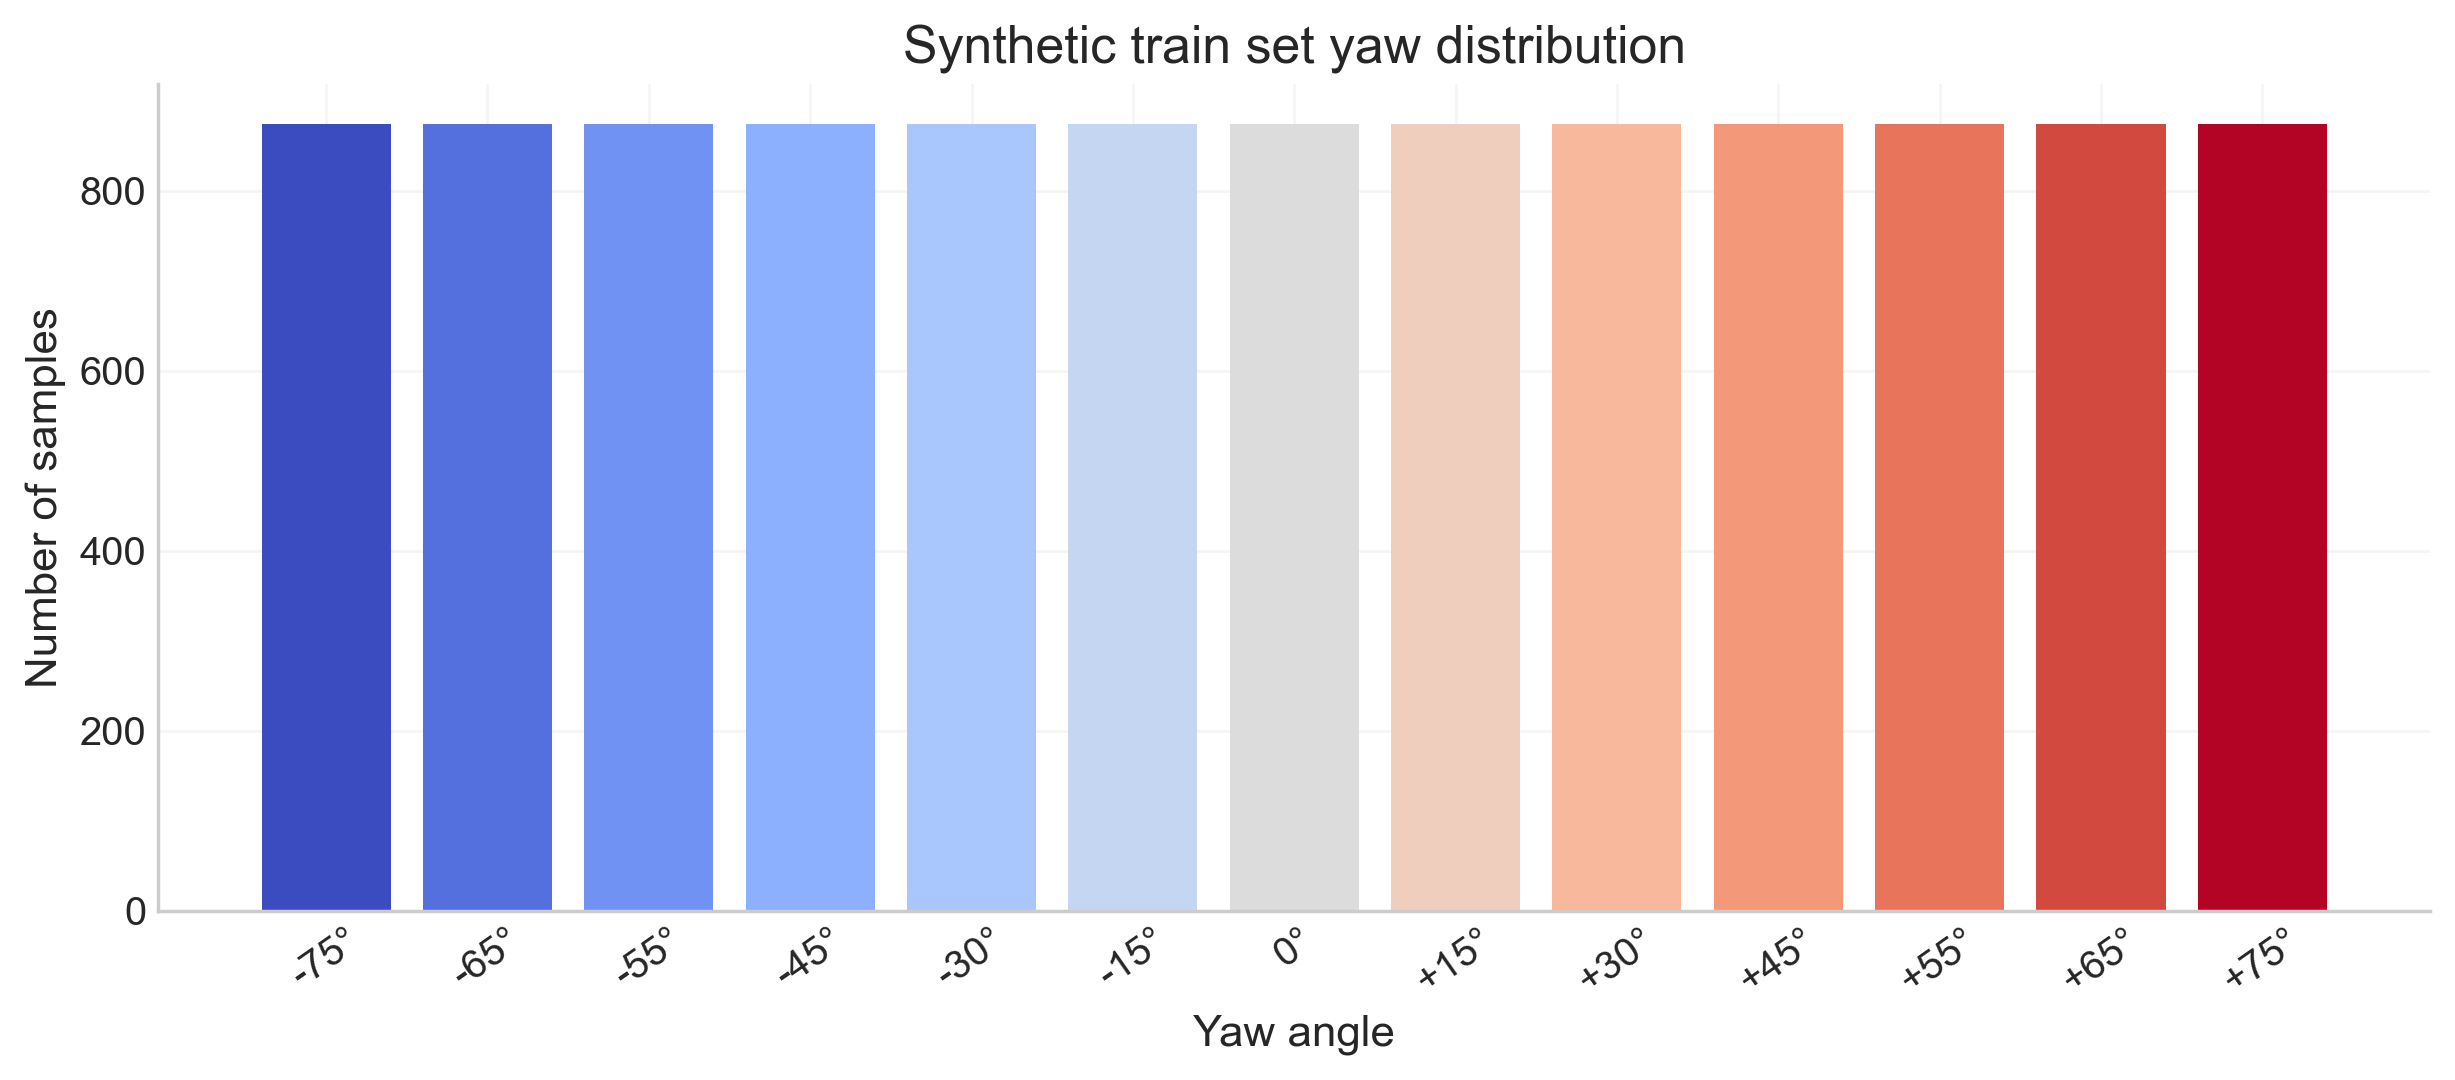

In [7]:
def plot_yaw_distribution(summary_df: pd.DataFrame, output_path: Path) -> None:
    """Plot sample count per yaw angle."""
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.bar(summary_df["yaw_label"], summary_df["n_samples"], color=[YAW_GROUP_COLORS[key] for key in summary_df["yaw_key"]])
    ax.set_title("Synthetic train set yaw distribution")
    ax.set_xlabel("Yaw angle")
    ax.set_ylabel("Number of samples")
    ax.tick_params(axis="x", rotation=35)
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()

plot_yaw_distribution(summary_df, FIGURES_DIR / "yaw_distribution_train.png")


In [8]:
def compute_visibility_table(visibility: np.ndarray, yaw_keys: np.ndarray) -> pd.DataFrame:
    """Compute visibility rate by landmark and yaw group."""
    rows = []
    for landmark_idx in range(visibility.shape[1]):
        for yaw_key in YAW_GROUP_ORDER:
            mask = yaw_keys == yaw_key
            rate = float(np.mean(visibility[mask, landmark_idx])) if np.any(mask) else np.nan
            rows.append(
                {
                    "landmark_idx": landmark_idx,
                    "landmark_number": landmark_idx + 1,
                    "anatomical_group": get_anatomical_group(landmark_idx),
                    "anatomical_label": get_anatomical_label(landmark_idx),
                    "yaw_angle": YAW_KEY_TO_ANGLE[yaw_key],
                    "yaw_key": yaw_key,
                    "yaw_label": YAW_KEY_TO_LABEL[yaw_key],
                    "visibility_rate": rate,
                }
            )
    return pd.DataFrame(rows)

visibility_table = compute_visibility_table(train_visibility, train_yaw_keys)
visibility_table.to_csv(TABLES_DIR / "visibility_rate_by_landmark_and_yaw.csv", index=False)
visibility_table.head()


,landmark_idx,landmark_number,anatomical_group,anatomical_label,yaw_angle,yaw_key,yaw_label,visibility_rate
0,0,1,face_contour,face_contour_1,-75.0,yaw_minus_75deg,-75°,0.0
1,0,1,face_contour,face_contour_1,-65.0,yaw_minus_65deg,-65°,0.0
2,0,1,face_contour,face_contour_1,-55.0,yaw_minus_55deg,-55°,0.0
3,0,1,face_contour,face_contour_1,-45.0,yaw_minus_45deg,-45°,0.0
4,0,1,face_contour,face_contour_1,-30.0,yaw_minus_30deg,-30°,0.0


In [9]:
def plot_visibility_heatmap(visibility_table: pd.DataFrame, output_path: Path) -> None:
    """Plot visibility rate heatmap by yaw group and landmark."""
    pivot = visibility_table.pivot(index="yaw_label", columns="landmark_number", values="visibility_rate")
    pivot = pivot.loc[[YAW_KEY_TO_LABEL[key] for key in YAW_GROUP_ORDER]]
    fig, ax = plt.subplots(figsize=(16, 5.5))
    image = ax.imshow(pivot.values, aspect="auto", vmin=0, vmax=1)
    ax.set_title("Visibility rate by yaw angle and landmark")
    ax.set_xlabel("Landmark number")
    ax.set_ylabel("Yaw angle")
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xticks(np.arange(0, NUM_LANDMARKS, 5))
    ax.set_xticklabels(np.arange(1, NUM_LANDMARKS + 1, 5))
    fig.colorbar(image, ax=ax, label="Visibility rate")
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()

if RUN_YAW_GROUP_ANALYSIS:
    plot_visibility_heatmap(visibility_table, FIGURES_DIR / "visibility_rate_heatmap_train_by_yaw.png")
else:
    print("Per-yaw visibility heatmap skipped because RUN_YAW_GROUP_ANALYSIS=False.")


Per-yaw visibility heatmap skipped because RUN_YAW_GROUP_ANALYSIS=False.


## Shape normalization and Procrustes alignment

Two global representations are always compared:

1. **Center and scale normalization**: removes translation and scale, while preserving residual pose/yaw geometry.
2. **Global generalized Procrustes alignment**: removes translation, scale, and rotation relative to one global reference shape.

If `RUN_YAW_GROUP_ANALYSIS = True`, the notebook also builds a yaw-conditioned Procrustes representation for descriptive analysis only.


In [10]:
def center_scale_shape(shape: np.ndarray, eps: float = 1e-8) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    """
    Center and scale-normalize a landmark shape.

    Args:
        shape: Landmark coordinates with shape [N, 2].
        eps: Numerical stability constant.

    Returns:
        A tuple with normalized shape and transformation metadata.
    """
    centroid = shape.mean(axis=0)
    centered = shape - centroid
    scale = float(np.sqrt(np.mean(np.sum(centered ** 2, axis=1))))
    scale = max(scale, eps)
    normalized = centered / scale
    return normalized, {"centroid": centroid, "scale": np.asarray(scale)}


def normalize_shapes_center_scale(shapes: np.ndarray) -> Tuple[np.ndarray, List[Dict[str, np.ndarray]]]:
    """
    Apply center-scale normalization to multiple shapes.

    Args:
        shapes: Array with shape [M, N, 2].

    Returns:
        Normalized shapes and per-sample metadata.
    """
    normalized_shapes = []
    metadata = []
    for shape in shapes:
        normalized, transform = center_scale_shape(shape)
        normalized_shapes.append(normalized)
        metadata.append(transform)
    return np.stack(normalized_shapes, axis=0), metadata


def orthogonal_procrustes_align(source: np.ndarray, target: np.ndarray, allow_reflection: bool = False, eps: float = 1e-8) -> Tuple[np.ndarray, Dict[str, np.ndarray]]:
    """
    Align one source shape to a target shape using similarity Procrustes.

    Args:
        source: Source shape with shape [N, 2].
        target: Target/reference shape with shape [N, 2].
        allow_reflection: Whether to allow reflection in the rotation matrix.
        eps: Numerical stability constant.

    Returns:
        A tuple with aligned source shape and transformation metadata.
    """
    source_center = source.mean(axis=0)
    target_center = target.mean(axis=0)
    source_centered = source - source_center
    target_centered = target - target_center
    source_scale = max(float(np.sqrt(np.sum(source_centered ** 2))), eps)
    target_scale = max(float(np.sqrt(np.sum(target_centered ** 2))), eps)
    source_norm = source_centered / source_scale
    target_norm = target_centered / target_scale
    covariance = source_norm.T @ target_norm
    left_singular, _, right_singular_t = np.linalg.svd(covariance)
    rotation = left_singular @ right_singular_t
    if not allow_reflection and np.linalg.det(rotation) < 0:
        left_singular[:, -1] *= -1
        rotation = left_singular @ right_singular_t
    aligned = source_norm @ rotation
    return aligned, {
        "source_center": source_center,
        "source_scale": np.asarray(source_scale),
        "target_center": target_center,
        "target_scale": np.asarray(target_scale),
        "rotation": rotation,
    }


def generalized_procrustes_align(shapes: np.ndarray, allow_reflection: bool = False, max_iterations: int = 50, tolerance: float = 1e-7) -> Tuple[np.ndarray, np.ndarray, List[Dict[str, np.ndarray]]]:
    """
    Align multiple shapes using generalized Procrustes analysis.

    Args:
        shapes: Array with shape [M, N, 2].
        allow_reflection: Whether to allow reflection in the alignment.
        max_iterations: Maximum number of iterations.
        tolerance: Convergence tolerance on reference shape update.

    Returns:
        A tuple with aligned shapes, reference mean shape, and per-sample transforms.
    """
    if shapes.ndim != 3 or shapes.shape[-1] != 2:
        raise ValueError(f"Expected shapes [M, N, 2], got {shapes.shape}.")

    centered_scaled, _ = normalize_shapes_center_scale(shapes)
    reference = centered_scaled.mean(axis=0)
    reference, _ = center_scale_shape(reference)
    aligned_shapes = centered_scaled
    final_transforms: List[Dict[str, np.ndarray]] = []

    for _ in range(max_iterations):
        aligned_list = []
        transforms = []
        for shape in shapes:
            aligned, transform = orthogonal_procrustes_align(shape, reference, allow_reflection=allow_reflection)
            aligned_list.append(aligned)
            transforms.append(transform)
        aligned_shapes = np.stack(aligned_list, axis=0)
        new_reference = aligned_shapes.mean(axis=0)
        new_reference, _ = center_scale_shape(new_reference)
        delta = float(np.linalg.norm(new_reference - reference))
        reference = new_reference
        final_transforms = transforms
        if delta < tolerance:
            break
    return aligned_shapes, reference, final_transforms


## PCA utilities

PCA is implemented using NumPy SVD to avoid external dependencies. Scores, reconstruction error, explained variance, and component visualization are all computed from the same representation.

In [11]:
@dataclass
class PCAResult:
    """
    Container for PCA results.

    Attributes:
        scope: Name of the PCA scope, for example 'global' or a yaw label.
        yaw_key: Optional yaw group key for yaw-conditioned PCA.
        yaw_label: Optional signed degree label for yaw-conditioned PCA.
        mean_vector: Mean shape vector with shape [D].
        components: Principal components with shape [K, D].
        explained_variance: Explained variance with shape [K].
        explained_variance_ratio: Explained variance ratio with shape [K].
        scores: PCA scores with shape [M, K].
        sample_indices: Original sample indices used to fit PCA.
        representation: Shape representation name.
    """
    scope: str
    yaw_key: Optional[str]
    yaw_label: Optional[str]
    mean_vector: np.ndarray
    components: np.ndarray
    explained_variance: np.ndarray
    explained_variance_ratio: np.ndarray
    scores: np.ndarray
    sample_indices: np.ndarray
    representation: str


def flatten_shapes(shapes: np.ndarray) -> np.ndarray:
    """Flatten shape coordinates from [M, N, 2] to [M, 2N]."""
    return shapes.reshape(shapes.shape[0], -1)


def unflatten_shape_vectors(vectors: np.ndarray, num_landmarks: int = NUM_LANDMARKS) -> np.ndarray:
    """Convert flattened vectors into landmark shapes."""
    array = np.asarray(vectors)
    if array.ndim == 1:
        return array.reshape(num_landmarks, 2)
    return array.reshape(array.shape[0], num_landmarks, 2)


def choose_num_components(
    singular_values: np.ndarray,
    n_samples: int,
    n_features: int,
    max_components: int = MAX_COMPONENTS_PER_PCA,
    explained_variance_threshold: float = EXPLAINED_VARIANCE_THRESHOLD,
    min_components: int = MIN_COMPONENTS_PER_PCA,
) -> int:
    """Choose PCA components using variance, while keeping enough PCs for figures."""
    if n_samples < 2:
        return 0
    explained_variance = (singular_values ** 2) / max(n_samples - 1, 1)
    total_variance = float(np.sum(explained_variance))
    if total_variance <= 0:
        return 0
    ratios = explained_variance / total_variance
    cumulative = np.cumsum(ratios)
    threshold_k = int(np.searchsorted(cumulative, explained_variance_threshold) + 1)
    safe_max = max(1, min(max_components, n_samples - 1, n_features, len(singular_values)))
    requested_k = max(threshold_k, min_components)
    return int(min(requested_k, safe_max))


def fit_pca(
    vectors: np.ndarray,
    scope: str,
    sample_indices: np.ndarray,
    representation: str,
    yaw_key: Optional[str] = None,
    yaw_label: Optional[str] = None,
    max_components: int = MAX_COMPONENTS_PER_PCA,
    explained_variance_threshold: float = EXPLAINED_VARIANCE_THRESHOLD,
    min_components: int = MIN_COMPONENTS_PER_PCA,
) -> PCAResult:
    """Fit PCA with SVD."""
    if vectors.ndim != 2:
        raise ValueError(f"Expected vectors [M, D], got {vectors.shape}.")
    n_samples, n_features = vectors.shape
    mean_vector = vectors.mean(axis=0)
    centered = vectors - mean_vector
    if n_samples < 2:
        return PCAResult(scope, yaw_key, yaw_label, mean_vector, np.zeros((0, n_features)), np.zeros((0,)), np.zeros((0,)), np.zeros((n_samples, 0)), sample_indices, representation)
    _, singular_values, vt = np.linalg.svd(centered, full_matrices=False)
    k = choose_num_components(singular_values, n_samples, n_features, max_components, explained_variance_threshold, min_components)
    explained_variance_full = (singular_values ** 2) / max(n_samples - 1, 1)
    total_variance = float(np.sum(explained_variance_full))
    explained_ratio_full = explained_variance_full / total_variance if total_variance > 0 else np.zeros_like(explained_variance_full)
    components = vt[:k]
    scores = centered @ components.T
    return PCAResult(scope, yaw_key, yaw_label, mean_vector, components, explained_variance_full[:k], explained_ratio_full[:k], scores, sample_indices, representation)


def reconstruct_from_pca(pca: PCAResult, vectors: np.ndarray) -> np.ndarray:
    """Reconstruct vectors from a PCA subspace."""
    if pca.components.shape[0] == 0:
        return np.repeat(pca.mean_vector[None, :], vectors.shape[0], axis=0)
    centered = vectors - pca.mean_vector
    scores = centered @ pca.components.T
    return pca.mean_vector + scores @ pca.components


def compute_reconstruction_error(vectors: np.ndarray, reconstructed: np.ndarray) -> np.ndarray:
    """Compute RMS reconstruction error per sample."""
    return np.sqrt(np.mean((vectors - reconstructed) ** 2, axis=1))


## Build shape representations

This cell always builds center-scale and global Procrustes representations. Per-yaw Procrustes representations are built only when `RUN_YAW_GROUP_ANALYSIS = True`.


In [ ]:
train_shapes_center_scale, center_scale_metadata = normalize_shapes_center_scale(train_landmarks)
train_vectors_center_scale = flatten_shapes(train_shapes_center_scale)

train_shapes_procrustes_global, global_procrustes_reference, global_procrustes_metadata = generalized_procrustes_align(
    train_landmarks,
    allow_reflection=ALLOW_REFLECTION,
    max_iterations=PROCRUSTES_MAX_ITERATIONS,
    tolerance=PROCRUSTES_TOLERANCE,
)
train_vectors_procrustes_global = flatten_shapes(train_shapes_procrustes_global)

print("Representations created:")
print(f"Center-scale vectors       : {train_vectors_center_scale.shape}")
print(f"Global Procrustes vectors  : {train_vectors_procrustes_global.shape}")


In [ ]:
def build_yaw_conditioned_procrustes_representations(landmarks: np.ndarray, yaw_keys: np.ndarray) -> Tuple[np.ndarray, Dict[str, np.ndarray], Dict[str, List[Dict[str, np.ndarray]]]]:
    """Build yaw-conditioned Procrustes-aligned shape representation."""
    aligned_shapes = np.zeros_like(landmarks, dtype=np.float64)
    references: Dict[str, np.ndarray] = {}
    transforms_by_yaw: Dict[str, List[Dict[str, np.ndarray]]] = {}
    for yaw_key in YAW_GROUP_ORDER:
        mask = yaw_keys == yaw_key
        indices = np.where(mask)[0]
        if len(indices) == 0:
            continue
        yaw_shapes = landmarks[indices]
        aligned, reference, transforms = generalized_procrustes_align(
            yaw_shapes,
            allow_reflection=ALLOW_REFLECTION,
            max_iterations=PROCRUSTES_MAX_ITERATIONS,
            tolerance=PROCRUSTES_TOLERANCE,
        )
        aligned_shapes[indices] = aligned
        references[yaw_key] = reference
        transforms_by_yaw[yaw_key] = transforms
    return aligned_shapes, references, transforms_by_yaw

if RUN_YAW_GROUP_ANALYSIS:
    train_shapes_procrustes_by_yaw, yaw_procrustes_references, yaw_procrustes_metadata = build_yaw_conditioned_procrustes_representations(train_landmarks, train_yaw_keys)
    train_vectors_procrustes_by_yaw = flatten_shapes(train_shapes_procrustes_by_yaw)
    print(f"Yaw-conditioned Procrustes vectors: {train_vectors_procrustes_by_yaw.shape}")
else:
    train_shapes_procrustes_by_yaw = None
    train_vectors_procrustes_by_yaw = None
    yaw_procrustes_references = {}
    yaw_procrustes_metadata = {}
    print("Yaw-conditioned Procrustes skipped because RUN_YAW_GROUP_ANALYSIS=False.")


Yaw-conditioned Procrustes skipped because RUN_YAW_GROUP_ANALYSIS=False.


## Mean shapes and landmark variability

Global mean shapes and variability are always computed. Per-yaw mean shapes and variability are computed only when `RUN_YAW_GROUP_ANALYSIS = True`.


In [ ]:
def plot_shape(ax: plt.Axes, shape: np.ndarray, title: str, point_size: int = 18, line_width: float = 1.0) -> None:
    """Plot a landmark shape with group-wise connections."""
    groups = {
        "face_contour": list(range(0, 17)),
        "right_eyebrow": list(range(17, 22)),
        "left_eyebrow": list(range(22, 27)),
        "nose_bridge": list(range(27, 31)),
        "nose_base": list(range(31, 36)),
        "right_eye": [36, 37, 38, 39, 40, 41, 36],
        "left_eye": [42, 43, 44, 45, 46, 47, 42],
        "outer_lip": [48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 48],
        "inner_lip": [60, 61, 62, 63, 64, 65, 66, 67, 60],
        "upper_chin": [68, 69],
        "lower_chin": [70, 71],
    }
    for _, indices in groups.items():
        valid_indices = [idx for idx in indices if idx < shape.shape[0]]
        if len(valid_indices) >= 2:
            ax.plot(shape[valid_indices, 0], shape[valid_indices, 1], linewidth=line_width)
    ax.scatter(shape[:, 0], shape[:, 1], s=point_size)
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.invert_yaxis()
    ax.axis("off")


def plot_mean_shapes_by_yaw(shapes: np.ndarray, yaw_keys: np.ndarray, output_path: Path, title: str) -> None:
    """Plot mean shape for each yaw group."""
    n_groups = len(YAW_GROUP_ORDER)
    n_cols = min(5, n_groups)
    n_rows = int(math.ceil(n_groups / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.4 * n_cols, 3.4 * n_rows))
    axes = np.asarray(axes).reshape(-1)
    for ax, yaw_key in zip(axes, YAW_GROUP_ORDER):
        mask = yaw_keys == yaw_key
        if np.any(mask):
            mean_shape = shapes[mask].mean(axis=0)
            plot_shape(ax, mean_shape, YAW_KEY_TO_LABEL[yaw_key])
        else:
            ax.set_title(f"{YAW_KEY_TO_LABEL[yaw_key]}\n(no samples)")
            ax.axis("off")
    for ax in axes[n_groups:]:
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()

if RUN_YAW_GROUP_ANALYSIS:
    plot_mean_shapes_by_yaw(train_shapes_center_scale, train_yaw_keys, FIGURES_DIR / "mean_shapes_by_yaw_center_scale.png", "Mean shapes by yaw, center-scale normalized")
    plot_mean_shapes_by_yaw(train_shapes_procrustes_by_yaw, train_yaw_keys, FIGURES_DIR / "mean_shapes_by_yaw_procrustes_by_yaw.png", "Mean shapes by yaw, yaw-conditioned Procrustes")
else:
    print("Per-yaw mean-shape plots skipped because RUN_YAW_GROUP_ANALYSIS=False.")


Per-yaw mean-shape plots skipped because RUN_YAW_GROUP_ANALYSIS=False.


In [ ]:
def compute_landmark_variability(shapes: np.ndarray, visibility: np.ndarray, yaw_keys: np.ndarray, representation: str, include_yaw_groups: bool = False) -> pd.DataFrame:
    """Compute landmark variability globally and optionally by yaw group."""
    rows = []
    scopes = [("global", None, None, np.ones(len(shapes), dtype=bool))]
    if include_yaw_groups:
        for yaw_key in YAW_GROUP_ORDER:
            scopes.append((YAW_KEY_TO_LABEL[yaw_key], yaw_key, YAW_KEY_TO_ANGLE[yaw_key], yaw_keys == yaw_key))
    for scope_name, yaw_key, yaw_angle, mask in scopes:
        if not np.any(mask):
            continue
        scope_shapes = shapes[mask]
        scope_visibility = visibility[mask]
        for landmark_idx in range(shapes.shape[1]):
            coords = scope_shapes[:, landmark_idx, :]
            std_x = float(np.std(coords[:, 0]))
            std_y = float(np.std(coords[:, 1]))
            spatial_std = float(np.sqrt(std_x ** 2 + std_y ** 2))
            rows.append(
                {
                    "representation": representation,
                    "scope": scope_name,
                    "yaw_key": yaw_key,
                    "yaw_angle": yaw_angle,
                    "yaw_label": scope_name if yaw_key is not None else None,
                    "landmark_idx": landmark_idx,
                    "landmark_number": landmark_idx + 1,
                    "anatomical_group": get_anatomical_group(landmark_idx),
                    "anatomical_label": get_anatomical_label(landmark_idx),
                    "mean_x": float(np.mean(coords[:, 0])),
                    "mean_y": float(np.mean(coords[:, 1])),
                    "std_x": std_x,
                    "std_y": std_y,
                    "spatial_std": spatial_std,
                    "visibility_rate": float(np.mean(scope_visibility[:, landmark_idx])),
                    "n_samples": int(scope_shapes.shape[0]),
                }
            )
    return pd.DataFrame(rows)

variability_frames = [
    compute_landmark_variability(train_shapes_center_scale, train_visibility, train_yaw_keys, representation="center_scale", include_yaw_groups=RUN_YAW_GROUP_ANALYSIS),
    compute_landmark_variability(train_shapes_procrustes_global, train_visibility, train_yaw_keys, representation="global_procrustes", include_yaw_groups=RUN_YAW_GROUP_ANALYSIS),
]
if RUN_YAW_GROUP_ANALYSIS and train_shapes_procrustes_by_yaw is not None:
    variability_frames.append(
        compute_landmark_variability(train_shapes_procrustes_by_yaw, train_visibility, train_yaw_keys, representation="yaw_procrustes", include_yaw_groups=True)
    )
landmark_variability = pd.concat(variability_frames, ignore_index=True)
landmark_variability.to_csv(TABLES_DIR / "landmark_variability.csv", index=False)
landmark_variability.query("scope == 'global' and representation == 'center_scale'").sort_values("spatial_std", ascending=False).head(15)


,representation,scope,yaw_key,yaw_angle,yaw_label,landmark_idx,landmark_number,anatomical_group,anatomical_label,mean_x,mean_y,std_x,std_y,spatial_std,visibility_rate,n_samples
16,center_scale,global,None,None,None,16,17,face_contour,face_contour_17,1.011587,-0.305031,1.134347,0.085641,1.137575,0.447385,11375
0,center_scale,global,None,None,None,0,1,face_contour,face_contour_1,-1.015250,-0.327664,1.133044,0.100750,1.137515,0.445802,11375
1,center_scale,global,None,None,None,1,2,face_contour,face_contour_2,-0.962475,0.131353,1.052392,0.117979,1.058984,0.454154,11375
15,center_scale,global,None,None,None,15,16,face_contour,face_contour_16,0.950755,0.163157,1.044582,0.109910,1.050348,0.445626,11375
2,center_scale,global,None,None,None,2,3,face_contour,face_contour_3,-0.903027,0.370229,1.023477,0.115069,1.029925,0.425846,11375
14,center_scale,global,None,None,None,14,15,face_contour,face_contour_15,0.892280,0.407574,1.010291,0.113749,1.016674,0.426725,11375
3,center_scale,global,None,None,None,3,4,face_contour,face_contour_4,-0.862602,0.577141,0.837759,0.117383,0.845942,0.445714,11375
13,center_scale,global,None,None,None,13,14,face_contour,face_contour_14,0.854184,0.606311,0.817735,0.119205,0.826378,0.447912,11375
4,center_scale,global,None,None,None,4,5,face_contour,face_contour_5,-0.814093,0.715937,0.684401,0.121842,0.695162,0.466374,11375
12,center_scale,global,None,None,None,12,13,face_contour,face_contour_13,0.810011,0.741145,0.666807,0.124291,0.678292,0.478857,11375


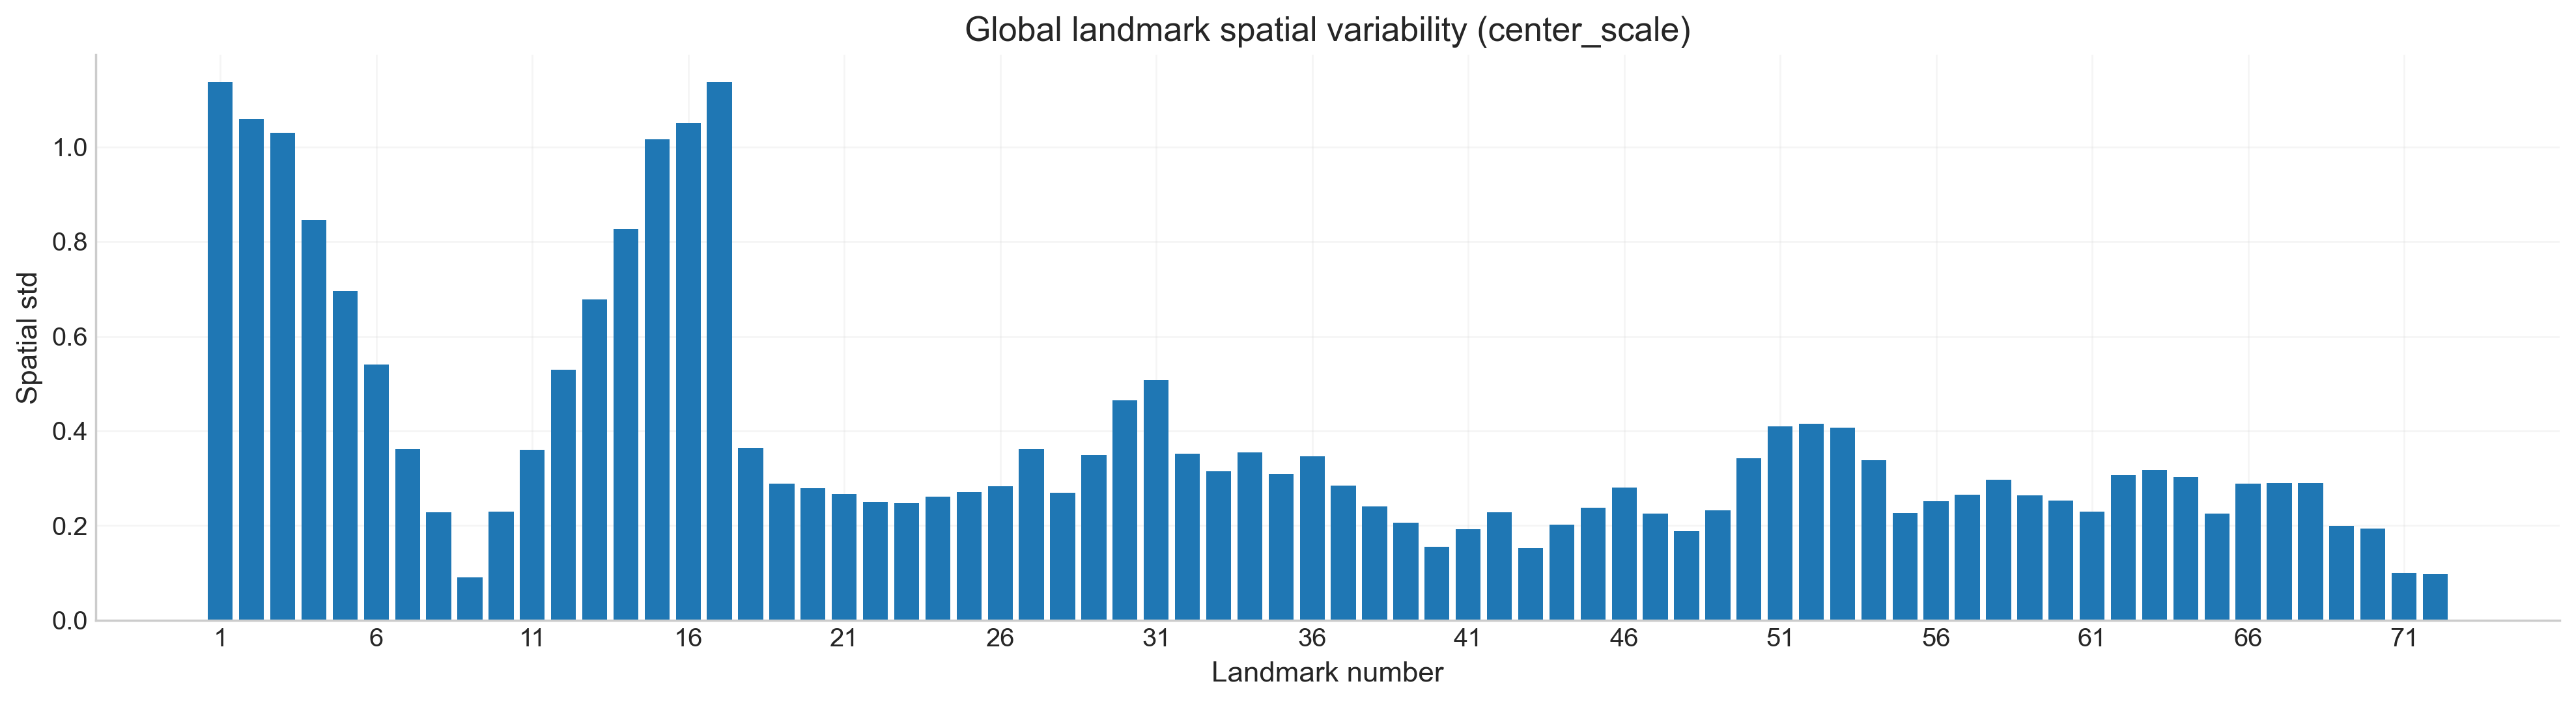

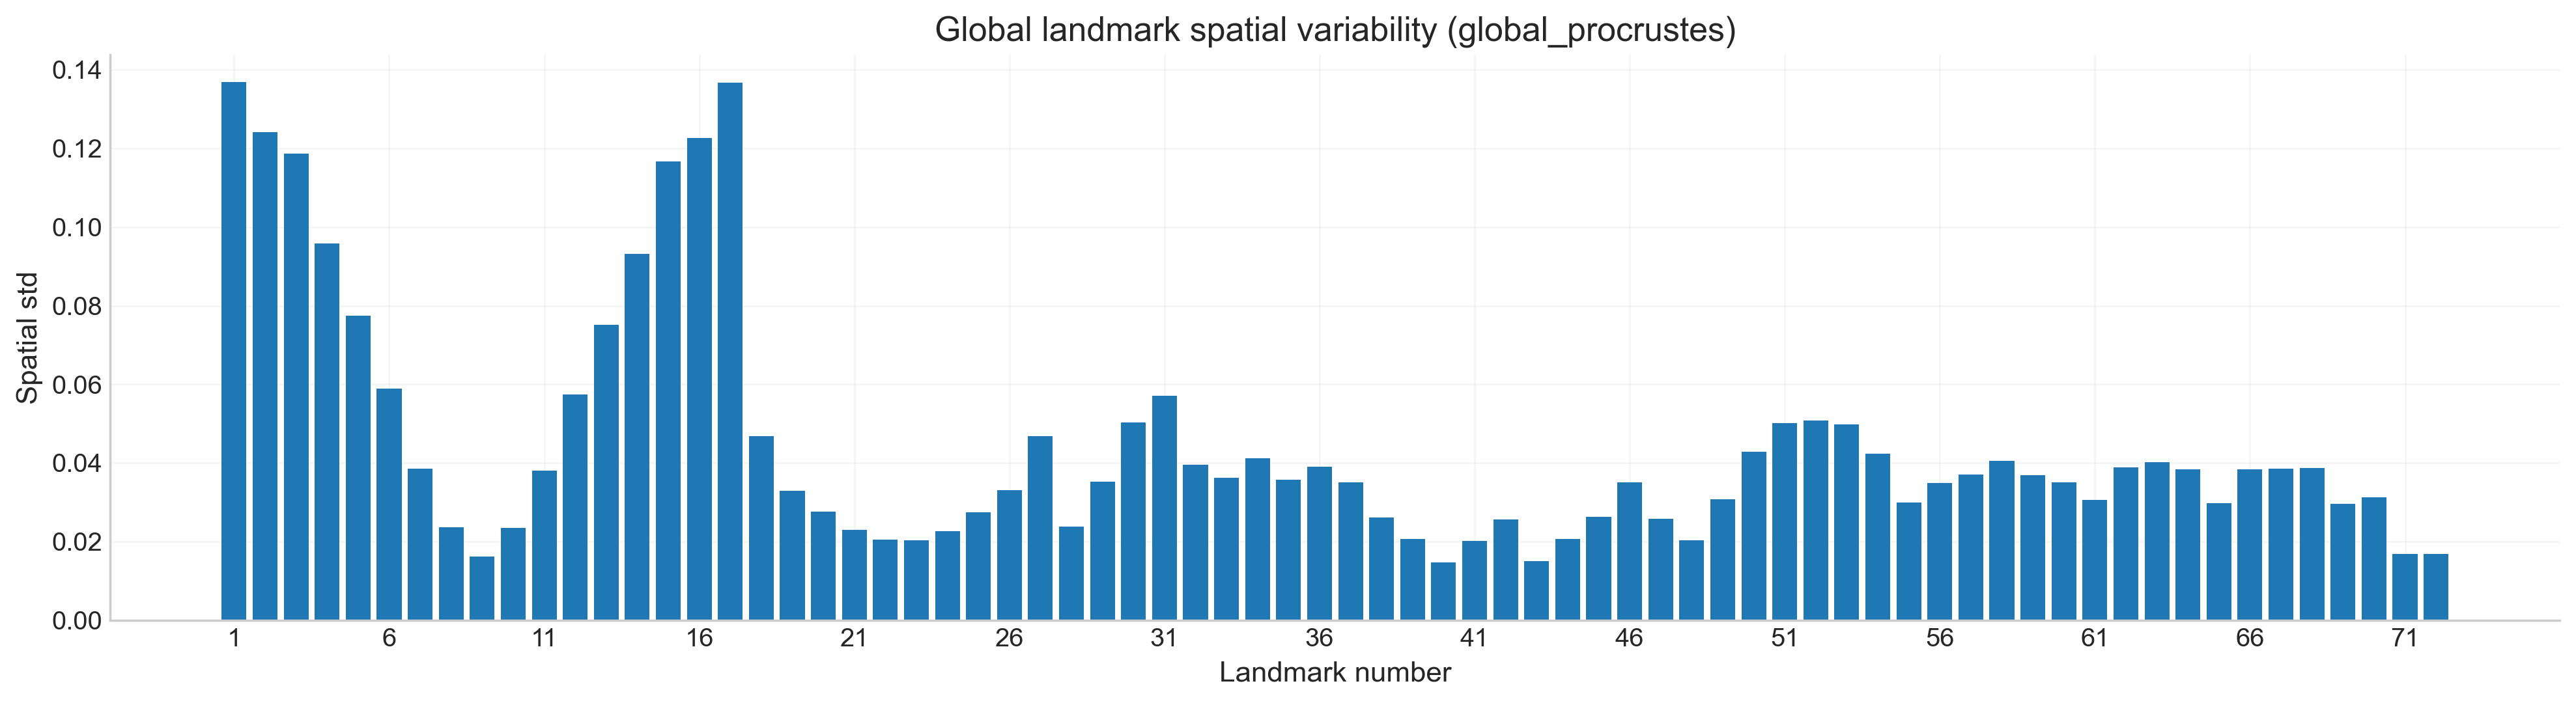

In [ ]:
def plot_landmark_variability(variability_df: pd.DataFrame, representation: str, output_path: Path) -> None:
    """Plot global landmark spatial variability by landmark."""
    subset = variability_df.query("scope == 'global' and representation == @representation").copy()
    subset = subset.sort_values("landmark_idx")
    fig, ax = plt.subplots(figsize=(16, 4.5))
    ax.bar(subset["landmark_number"], subset["spatial_std"])
    ax.set_title(f"Global landmark spatial variability ({representation})")
    ax.set_xlabel("Landmark number")
    ax.set_ylabel("Spatial std")
    ax.set_xticks(np.arange(1, NUM_LANDMARKS + 1, 5))
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()

plot_landmark_variability(landmark_variability, "center_scale", FIGURES_DIR / "landmark_variability_center_scale.png")
plot_landmark_variability(landmark_variability, "global_procrustes", FIGURES_DIR / "landmark_variability_global_procrustes.png")


## PCA fitting: global by default, optional per-yaw

Global PCA is always fitted with all samples pooled together. Per-yaw PCA fits are created only when `RUN_YAW_GROUP_ANALYSIS = True`.


In [ ]:
def fit_global_and_optional_yaw_pcas(vectors: np.ndarray, yaw_keys: np.ndarray, representation: str, include_yaw_groups: bool = False) -> Dict[str, PCAResult]:
    """Fit one global PCA and optionally one PCA per yaw group."""
    pcas: Dict[str, PCAResult] = {}
    all_indices = np.arange(vectors.shape[0])
    pcas[f"global__{representation}"] = fit_pca(vectors, "global", all_indices, representation)
    if include_yaw_groups:
        for yaw_key in YAW_GROUP_ORDER:
            mask = yaw_keys == yaw_key
            indices = np.where(mask)[0]
            if len(indices) < 2:
                warnings.warn(f"Skipping PCA for yaw {YAW_KEY_TO_LABEL[yaw_key]}: fewer than 2 samples.")
                continue
            pcas[f"{yaw_key}__{representation}"] = fit_pca(
                vectors[indices],
                YAW_KEY_TO_LABEL[yaw_key],
                indices,
                representation,
                yaw_key=yaw_key,
                yaw_label=YAW_KEY_TO_LABEL[yaw_key],
            )
    return pcas

pca_results: Dict[str, PCAResult] = {}
pca_results.update(fit_global_and_optional_yaw_pcas(train_vectors_center_scale, train_yaw_keys, "center_scale", include_yaw_groups=RUN_YAW_GROUP_ANALYSIS))
pca_results.update(fit_global_and_optional_yaw_pcas(train_vectors_procrustes_global, train_yaw_keys, "global_procrustes", include_yaw_groups=RUN_YAW_GROUP_ANALYSIS))
if RUN_YAW_GROUP_ANALYSIS and train_vectors_procrustes_by_yaw is not None:
    pca_results.update(fit_global_and_optional_yaw_pcas(train_vectors_procrustes_by_yaw, train_yaw_keys, "yaw_procrustes", include_yaw_groups=True))

print(f"Fitted {len(pca_results)} PCA models.")
list(pca_results.keys())[:10]


Fitted 2 PCA models.


['global__center_scale', 'global__global_procrustes']

In [ ]:
def pca_explained_variance_table(pcas: Dict[str, PCAResult]) -> pd.DataFrame:
    """Build explained variance table for PCA models."""
    rows = []
    for key, pca in pcas.items():
        cumulative = np.cumsum(pca.explained_variance_ratio)
        for pc_idx, (variance, ratio, cumulative_ratio) in enumerate(zip(pca.explained_variance, pca.explained_variance_ratio, cumulative), start=1):
            rows.append(
                {
                    "pca_key": key,
                    "scope": pca.scope,
                    "yaw_key": pca.yaw_key,
                    "yaw_label": pca.yaw_label,
                    "representation": pca.representation,
                    "pc_idx": pc_idx,
                    "explained_variance": float(variance),
                    "explained_variance_ratio": float(ratio),
                    "cumulative_explained_variance_ratio": float(cumulative_ratio),
                    "n_samples": int(len(pca.sample_indices)),
                    "n_components": int(pca.components.shape[0]),
                }
            )
    return pd.DataFrame(rows)

explained_variance_df = pca_explained_variance_table(pca_results)
explained_variance_df.to_csv(TABLES_DIR / "pca_explained_variance.csv", index=False)
explained_variance_df.head()


,pca_key,scope,yaw_key,yaw_label,representation,pc_idx,explained_variance,explained_variance_ratio,cumulative_explained_variance_ratio,n_samples,n_components
0,global__center_scale,global,None,None,center_scale,1,12.301949,0.832094,0.832094,11375,2
1,global__center_scale,global,None,None,center_scale,2,2.087790,0.141216,0.973310,11375,2
2,global__global_procrustes,global,None,None,global_procrustes,1,0.165461,0.820765,0.820765,11375,2
3,global__global_procrustes,global,None,None,global_procrustes,2,0.030567,0.151627,0.972392,11375,2


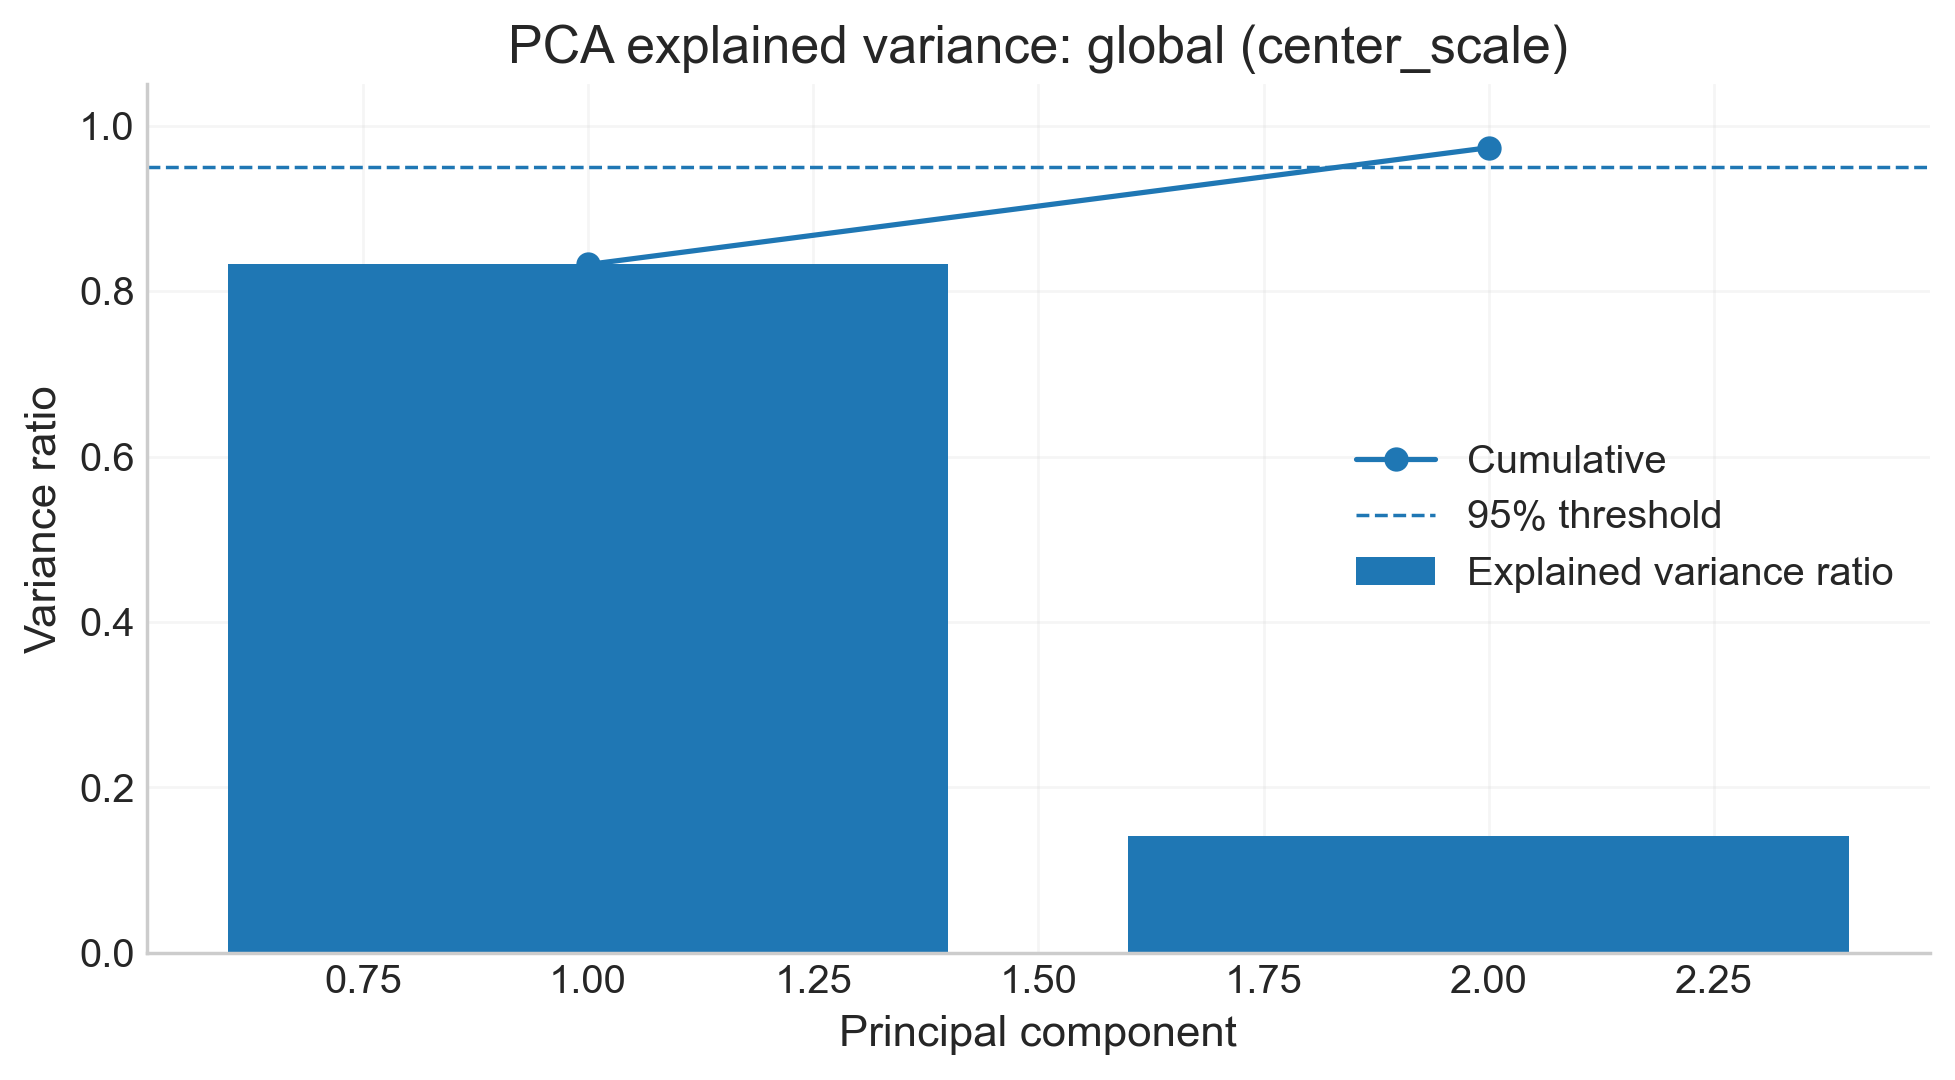

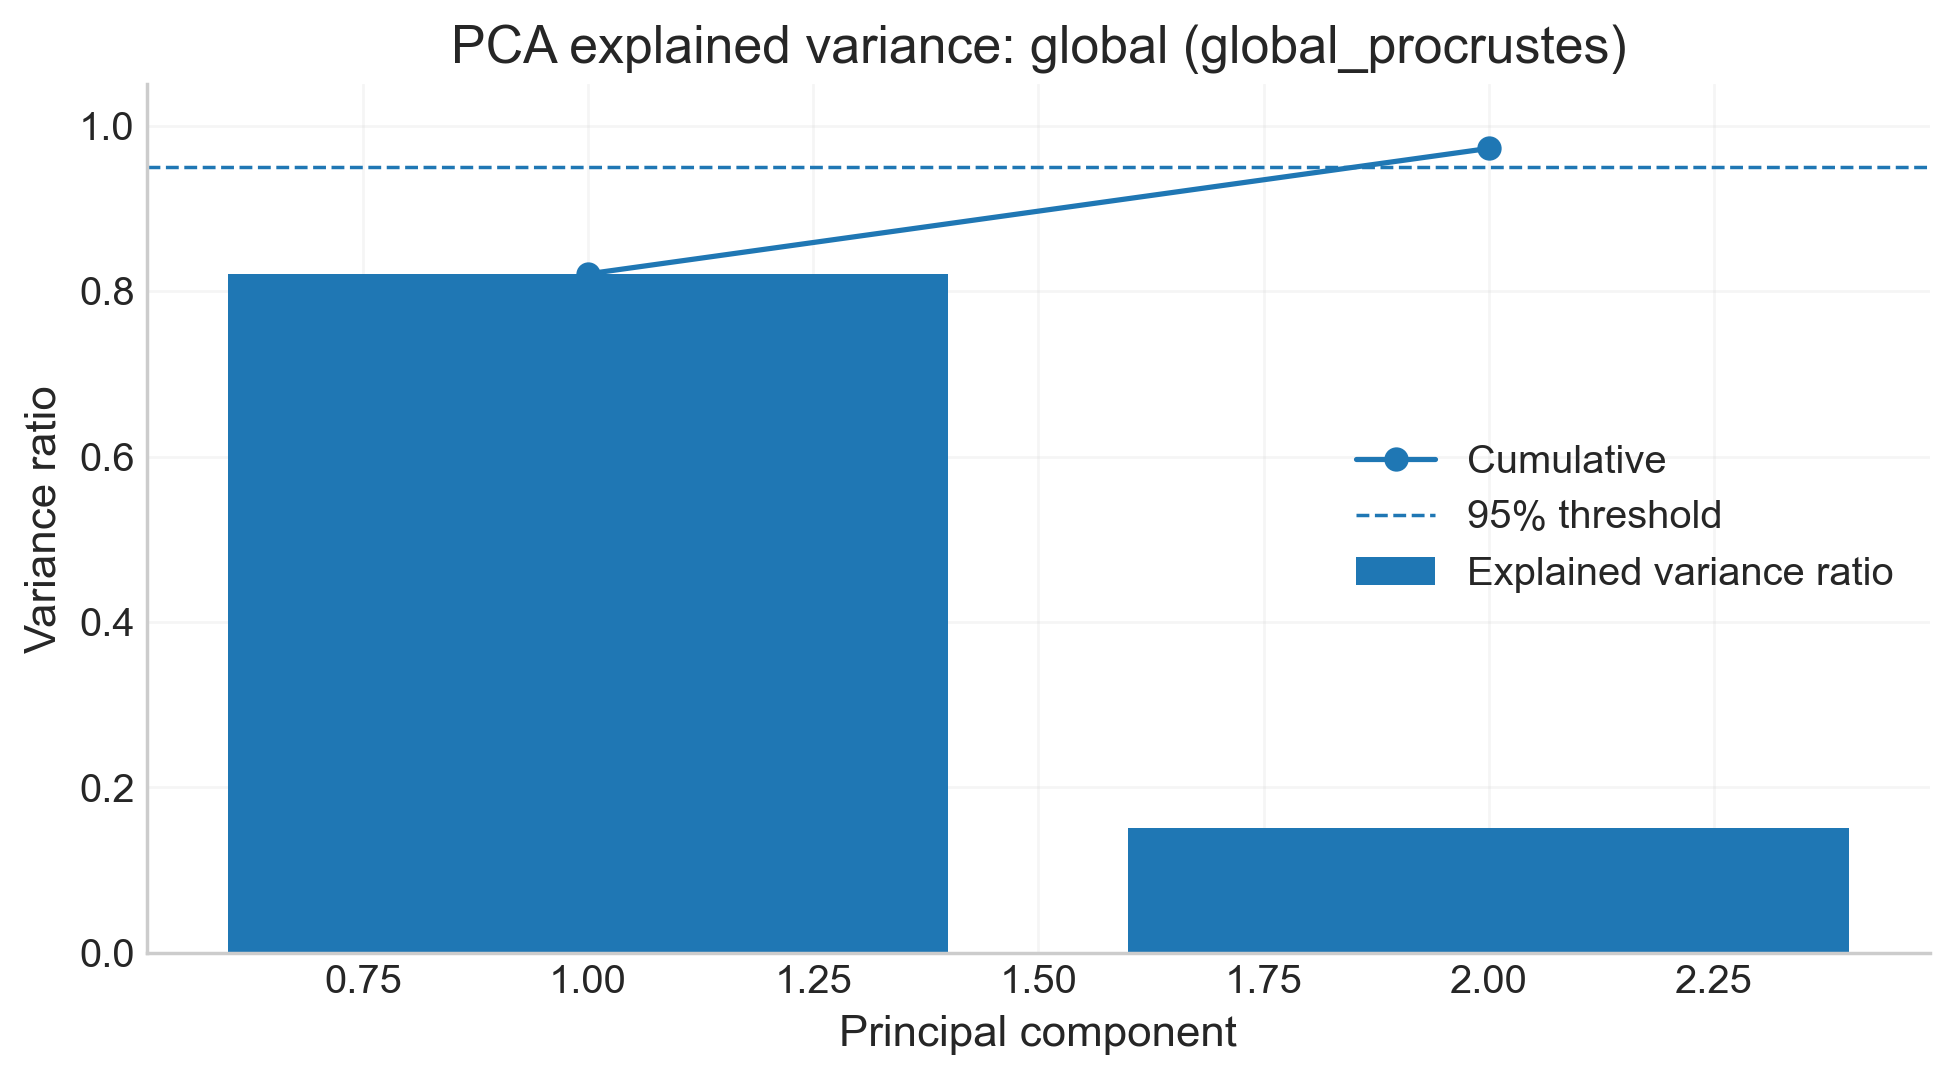

In [ ]:
def plot_explained_variance(pca: PCAResult, output_path: Path) -> None:
    """
    Plot explained variance ratio and cumulative explained variance for one PCA.

    Args:
        pca: PCAResult instance.
        output_path: Path where the figure will be saved.
    """
    if pca.components.shape[0] == 0:
        return
    pc_numbers = np.arange(1, len(pca.explained_variance_ratio) + 1)
    cumulative = np.cumsum(pca.explained_variance_ratio)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(pc_numbers, pca.explained_variance_ratio, label="Explained variance ratio")
    ax.plot(pc_numbers, cumulative, marker="o", label="Cumulative")
    ax.axhline(EXPLAINED_VARIANCE_THRESHOLD, linestyle="--", linewidth=1.0, label=f"{EXPLAINED_VARIANCE_THRESHOLD:.0%} threshold")
    ax.set_title(f"PCA explained variance: {pca.scope} ({pca.representation})")
    ax.set_xlabel("Principal component")
    ax.set_ylabel("Variance ratio")
    ax.set_ylim(0, 1.05)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()

for key in ["global__center_scale", "global__global_procrustes"]:
    if key in pca_results:
        plot_explained_variance(pca_results[key], FIGURES_DIR / f"explained_variance_{key}.png")


In [ ]:
def plot_explained_variance_by_yaw(representation: str, output_path: Path) -> None:
    """Plot cumulative explained variance for per-yaw PCA models."""
    if not RUN_YAW_GROUP_ANALYSIS:
        print(f"Skipping per-yaw cumulative variance plot for {representation} because RUN_YAW_GROUP_ANALYSIS=False.")
        return
    fig, ax = plt.subplots(figsize=(9, 5))
    for yaw_key in YAW_GROUP_ORDER:
        key = f"{yaw_key}__{representation}"
        if key not in pca_results:
            continue
        pca = pca_results[key]
        if pca.components.shape[0] == 0:
            continue
        pc_numbers = np.arange(1, len(pca.explained_variance_ratio) + 1)
        cumulative = np.cumsum(pca.explained_variance_ratio)
        ax.plot(pc_numbers, cumulative, marker="o", label=YAW_KEY_TO_LABEL[yaw_key], color=YAW_GROUP_COLORS[yaw_key])
    ax.axhline(EXPLAINED_VARIANCE_THRESHOLD, linestyle="--", linewidth=1.0, label=f"{EXPLAINED_VARIANCE_THRESHOLD:.0%} threshold")
    ax.set_title(f"Per-yaw PCA cumulative variance ({representation})")
    ax.set_xlabel("Principal component")
    ax.set_ylabel("Cumulative explained variance")
    ax.set_ylim(0, 1.05)
    ax.legend(ncol=2)
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()

plot_explained_variance_by_yaw("center_scale", FIGURES_DIR / "yaw_pca_cumulative_variance_center_scale.png")
if RUN_YAW_GROUP_ANALYSIS:
    plot_explained_variance_by_yaw("yaw_procrustes", FIGURES_DIR / "yaw_pca_cumulative_variance_yaw_procrustes.png")


Skipping per-yaw cumulative variance plot for center_scale because RUN_YAW_GROUP_ANALYSIS=False.


## Visualize PCA components

Each component plot shows `mean - alpha * sqrt(lambda) * PC`, `mean`, and `mean + alpha * sqrt(lambda) * PC`.

Use these figures to interpret whether a component captures yaw, contour deformation, mouth opening, chin variation, or other shape changes.

In [ ]:
def plot_pca_component_variation(pca: PCAResult, pc_idx: int, output_path: Path, alpha: float = COMPONENT_STD_MULTIPLIER) -> None:
    """Plot mean shape and +/- PCA component variation."""
    if pc_idx >= pca.components.shape[0]:
        return
    std = math.sqrt(float(pca.explained_variance[pc_idx]))
    mean_vector = pca.mean_vector
    component = pca.components[pc_idx]
    minus_shape = unflatten_shape_vectors(mean_vector - alpha * std * component)
    mean_shape = unflatten_shape_vectors(mean_vector)
    plus_shape = unflatten_shape_vectors(mean_vector + alpha * std * component)
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    plot_shape(axes[0], minus_shape, f"Mean - {alpha} SD PC{pc_idx + 1}")
    plot_shape(axes[1], mean_shape, "Mean")
    plot_shape(axes[2], plus_shape, f"Mean + {alpha} SD PC{pc_idx + 1}")
    fig.suptitle(f"{pca.scope} PCA component {pc_idx + 1} ({pca.representation})")
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()

for key in ["global__center_scale", "global__global_procrustes"]:
    pca = pca_results.get(key)
    if pca is None:
        continue
    for pc_idx in range(min(MAX_COMPONENTS_TO_VISUALIZE, pca.components.shape[0])):
        plot_pca_component_variation(pca, pc_idx, FIGURES_DIR / f"pca_component_{key}_pc{pc_idx + 1:02d}.png")

if RUN_YAW_GROUP_ANALYSIS:
    for representation in ["center_scale", "yaw_procrustes"]:
        for yaw_key in YAW_GROUP_ORDER:
            key = f"{yaw_key}__{representation}"
            pca = pca_results.get(key)
            if pca is None:
                continue
            for pc_idx in range(min(YAW_MAX_COMPONENTS_TO_VISUALIZE, pca.components.shape[0])):
                plot_pca_component_variation(pca, pc_idx, FIGURES_DIR / f"pca_component_{key}_pc{pc_idx + 1:02d}.png")


## PCA score distributions and normality

This section checks whether PCA component scores are approximately normal. A global PCA with multimodal PC scores can indicate that the PCA is mixing distinct yaw-driven shape modes.


In [ ]:
def compute_pca_score_statistics(pcas: Dict[str, PCAResult]) -> pd.DataFrame:
    """Compute descriptive and normality statistics for PCA scores."""
    rows = []
    for key, pca in pcas.items():
        for pc_idx in range(pca.scores.shape[1]):
            values = pca.scores[:, pc_idx]
            std = float(np.std(values))
            mean = float(np.mean(values))
            z_values = (values - mean) / (std + 1e-12)
            if SCIPY_AVAILABLE and len(values) >= 8:
                skewness = float(stats.skew(values, bias=False))
                excess_kurtosis = float(stats.kurtosis(values, fisher=True, bias=False))
                try:
                    shapiro_stat, shapiro_p = stats.shapiro(values) if len(values) <= 5000 else (np.nan, np.nan)
                except Exception:
                    shapiro_stat, shapiro_p = np.nan, np.nan
            else:
                centered = values - mean
                skewness = float(np.mean(centered ** 3) / ((std + 1e-12) ** 3)) if len(values) > 0 else np.nan
                excess_kurtosis = float(np.mean(centered ** 4) / ((std + 1e-12) ** 4) - 3.0) if len(values) > 0 else np.nan
                shapiro_stat, shapiro_p = np.nan, np.nan
            rows.append(
                {
                    "pca_key": key,
                    "scope": pca.scope,
                    "yaw_key": pca.yaw_key,
                    "yaw_label": pca.yaw_label,
                    "representation": pca.representation,
                    "pc_idx": pc_idx + 1,
                    "score_mean": mean,
                    "score_std": std,
                    "score_min": float(np.min(values)),
                    "score_max": float(np.max(values)),
                    "score_skewness": skewness,
                    "score_excess_kurtosis": excess_kurtosis,
                    "outlier_rate_abs_z_gt_3": float(np.mean(np.abs(z_values) > 3.0)),
                    "shapiro_statistic": float(shapiro_stat) if not np.isnan(shapiro_stat) else np.nan,
                    "shapiro_p_value": float(shapiro_p) if not np.isnan(shapiro_p) else np.nan,
                    "n_samples": int(len(values)),
                }
            )
    return pd.DataFrame(rows)

score_statistics = compute_pca_score_statistics(pca_results)
score_statistics.to_csv(TABLES_DIR / "pca_score_statistics.csv", index=False)
score_statistics.head(15)


,pca_key,scope,yaw_key,yaw_label,representation,pc_idx,score_mean,score_std,score_min,score_max,score_skewness,score_excess_kurtosis,outlier_rate_abs_z_gt_3,shapiro_statistic,shapiro_p_value,n_samples
0,global__center_scale,global,None,None,center_scale,1,-1.847645e-15,3.507259,-5.397244,5.362891,0.000402,-1.526897,0.0,NaN,NaN,11375
1,global__center_scale,global,None,None,center_scale,2,1.606607e-15,1.444855,-2.669998,2.706237,-0.169461,-1.231287,0.0,NaN,NaN,11375
2,global__global_procrustes,global,None,None,global_procrustes,1,8.437695e-17,0.406751,-0.633307,0.636066,0.002152,-1.534515,0.0,NaN,NaN,11375
3,global__global_procrustes,global,None,None,global_procrustes,2,2.016067e-16,0.174827,-0.330976,0.325375,-0.168531,-1.233857,0.0,NaN,NaN,11375


In [ ]:
def plot_score_histogram(pca: PCAResult, pc_idx: int, output_path: Path) -> None:
    """
    Plot histogram of PCA scores with optional normal density overlay.

    Args:
        pca: PCAResult instance.
        pc_idx: Zero-based component index.
        output_path: Path where the figure will be saved.
    """
    if pc_idx >= pca.scores.shape[1]:
        return
    values = pca.scores[:, pc_idx]
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.hist(values, bins=30, density=True, alpha=0.7, label="Scores")
    mean = float(np.mean(values))
    std = float(np.std(values))
    if std > 0:
        x_grid = np.linspace(values.min(), values.max(), 200)
        if SCIPY_AVAILABLE:
            y_grid = stats.norm.pdf(x_grid, loc=mean, scale=std)
        else:
            y_grid = (1.0 / (std * math.sqrt(2.0 * math.pi))) * np.exp(-0.5 * ((x_grid - mean) / std) ** 2)
        ax.plot(x_grid, y_grid, linewidth=2, label="Normal fit")
    ax.set_title(f"Score distribution: {pca.scope} PC{pc_idx + 1} ({pca.representation})")
    ax.set_xlabel("PCA score")
    ax.set_ylabel("Density")
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()


def plot_qq(pca: PCAResult, pc_idx: int, output_path: Path) -> None:
    """
    Plot Q-Q plot for PCA scores.

    Args:
        pca: PCAResult instance.
        pc_idx: Zero-based component index.
        output_path: Path where the figure will be saved.
    """
    if not SCIPY_AVAILABLE or pc_idx >= pca.scores.shape[1]:
        return
    values = pca.scores[:, pc_idx]
    fig, ax = plt.subplots(figsize=(5, 5))
    stats.probplot(values, dist="norm", plot=ax)
    ax.set_title(f"Q-Q plot: {pca.scope} PC{pc_idx + 1} ({pca.representation})")
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()

for key in ["global__center_scale", "global__global_procrustes"]:
    pca = pca_results.get(key)
    if pca is None:
        continue
    for pc_idx in range(min(SCORE_COMPONENTS_TO_VISUALIZE, pca.scores.shape[1])):
        plot_score_histogram(pca, pc_idx, FIGURES_DIR / f"score_hist_{key}_pc{pc_idx + 1:02d}.png")
        plot_qq(pca, pc_idx, FIGURES_DIR / f"qq_plot_{key}_pc{pc_idx + 1:02d}.png")


## Pairwise PCA score analysis

The scatter plots show whether global PCA scores cluster by yaw angle. The notebook now generates all pairwise score scatters among the first `SCORE_SCATTER_COMPONENTS_TO_PLOT` components, instead of only PC1/PC2 and PC1/PC3.


In [ ]:
def plot_pca_score_scatter(pca: PCAResult, sample_yaw_keys: np.ndarray, output_path: Path, pc_x: int = 0, pc_y: int = 1) -> None:
    """Plot PCA score scatter colored by yaw angle."""
    if pca.scores.shape[1] <= max(pc_x, pc_y):
        return
    yaw_keys_for_pca = sample_yaw_keys[pca.sample_indices]
    fig, ax = plt.subplots(figsize=(7, 6))
    for yaw_key in YAW_GROUP_ORDER:
        mask = yaw_keys_for_pca == yaw_key
        if not np.any(mask):
            continue
        ax.scatter(pca.scores[mask, pc_x], pca.scores[mask, pc_y], s=18, alpha=0.75, label=YAW_KEY_TO_LABEL[yaw_key], color=YAW_GROUP_COLORS[yaw_key])
    ax.set_title(f"PCA score scatter: {pca.scope} ({pca.representation})")
    ax.set_xlabel(f"PC{pc_x + 1}")
    ax.set_ylabel(f"PC{pc_y + 1}")
    ax.legend(ncol=2)
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()

def plot_score_scatter_pairs(
    pca: PCAResult,
    sample_yaw_keys: np.ndarray,
    output_dir: Path,
    key: str,
    max_components: int = SCORE_SCATTER_COMPONENTS_TO_PLOT,
) -> None:
    """Plot all pairwise score scatters among the first N PCs."""
    num_components = min(max_components, pca.scores.shape[1])
    for pc_x in range(num_components):
        for pc_y in range(pc_x + 1, num_components):
            plot_pca_score_scatter(
                pca,
                sample_yaw_keys,
                output_dir / f"score_scatter_{key}_pc{pc_x + 1}_pc{pc_y + 1}.png",
                pc_x=pc_x,
                pc_y=pc_y,
            )

for key in ["global__center_scale", "global__global_procrustes"]:
    pca = pca_results.get(key)
    if pca is not None:
        plot_score_scatter_pairs(pca, train_yaw_keys, FIGURES_DIR, key)


In [ ]:
def plot_pairwise_score_grid(pca: PCAResult, sample_yaw_keys: np.ndarray, output_path: Path, num_pcs: int = SCORE_GRID_COMPONENTS) -> None:
    """Plot pairwise scatter matrix for PCA scores colored by yaw angle."""
    num_pcs = min(num_pcs, pca.scores.shape[1])
    if num_pcs < 2:
        return
    yaw_keys_for_pca = sample_yaw_keys[pca.sample_indices]
    fig, axes = plt.subplots(num_pcs, num_pcs, figsize=(2.8 * num_pcs, 2.8 * num_pcs))
    for i in range(num_pcs):
        for j in range(num_pcs):
            ax = axes[i, j]
            if i == j:
                ax.hist(pca.scores[:, i], bins=20, alpha=0.8)
            else:
                for yaw_key in YAW_GROUP_ORDER:
                    mask = yaw_keys_for_pca == yaw_key
                    if np.any(mask):
                        ax.scatter(pca.scores[mask, j], pca.scores[mask, i], s=8, alpha=0.5, color=YAW_GROUP_COLORS[yaw_key])
            if i == num_pcs - 1:
                ax.set_xlabel(f"PC{j + 1}")
            else:
                ax.set_xticks([])
            if j == 0:
                ax.set_ylabel(f"PC{i + 1}")
            else:
                ax.set_yticks([])
    fig.suptitle(f"Pairwise PCA score grid: {pca.scope} ({pca.representation})")
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()

for key in ["global__center_scale", "global__global_procrustes"]:
    pca = pca_results.get(key)
    if pca is not None:
        plot_pairwise_score_grid(pca, train_yaw_keys, FIGURES_DIR / f"pairwise_score_grid_{key}.png", num_pcs=SCORE_GRID_COMPONENTS)


## Pairwise yaw distances

Pairwise yaw-distance tables and heatmaps are optional and only run when `RUN_YAW_GROUP_ANALYSIS = True`.


In [ ]:
def compute_pairwise_yaw_distances(vectors: np.ndarray, yaw_keys: np.ndarray, representation: str) -> pd.DataFrame:
    """Compute pairwise distances between yaw groups."""
    rows = []
    for yaw_a in YAW_GROUP_ORDER:
        vectors_a = vectors[yaw_keys == yaw_a]
        if len(vectors_a) == 0:
            continue
        for yaw_b in YAW_GROUP_ORDER:
            vectors_b = vectors[yaw_keys == yaw_b]
            if len(vectors_b) == 0:
                continue
            if yaw_a == yaw_b and len(vectors_a) > 1:
                distance_matrix = np.sqrt(((vectors_a[:, None, :] - vectors_a[None, :, :]) ** 2).mean(axis=2))
                distances = distance_matrix[np.triu_indices_from(distance_matrix, k=1)]
            else:
                distances = np.sqrt(((vectors_a[:, None, :] - vectors_b[None, :, :]) ** 2).mean(axis=2)).reshape(-1)
            rows.append(
                {
                    "representation": representation,
                    "yaw_a_key": yaw_a,
                    "yaw_a_label": YAW_KEY_TO_LABEL[yaw_a],
                    "yaw_a_angle": YAW_KEY_TO_ANGLE[yaw_a],
                    "yaw_b_key": yaw_b,
                    "yaw_b_label": YAW_KEY_TO_LABEL[yaw_b],
                    "yaw_b_angle": YAW_KEY_TO_ANGLE[yaw_b],
                    "mean_distance": float(np.mean(distances)) if len(distances) else np.nan,
                    "median_distance": float(np.median(distances)) if len(distances) else np.nan,
                    "std_distance": float(np.std(distances)) if len(distances) else np.nan,
                    "n_distances": int(len(distances)),
                    "is_within_yaw": yaw_a == yaw_b,
                }
            )
    return pd.DataFrame(rows)

if RUN_YAW_GROUP_ANALYSIS:
    pairwise_distances_center = compute_pairwise_yaw_distances(train_vectors_center_scale, train_yaw_keys, "center_scale")
    pairwise_distance_frames = [pairwise_distances_center]
    if train_vectors_procrustes_by_yaw is not None:
        pairwise_distance_frames.append(compute_pairwise_yaw_distances(train_vectors_procrustes_by_yaw, train_yaw_keys, "yaw_procrustes"))
    pairwise_distances = pd.concat(pairwise_distance_frames, ignore_index=True)
else:
    pairwise_distances = pd.DataFrame()

if not pairwise_distances.empty:
    pairwise_distances.to_csv(TABLES_DIR / "pairwise_yaw_distances.csv", index=False)

pairwise_distances.head()


""


In [ ]:
def plot_pairwise_distance_heatmap(distance_df: pd.DataFrame, representation: str, output_path: Path) -> None:
    """Plot pairwise yaw mean distance heatmap."""
    subset = distance_df.query("representation == @representation")
    if subset.empty:
        return
    pivot = subset.pivot(index="yaw_a_label", columns="yaw_b_label", values="mean_distance")
    order = [YAW_KEY_TO_LABEL[key] for key in YAW_GROUP_ORDER]
    pivot = pivot.loc[order, order]
    fig, ax = plt.subplots(figsize=(8, 7))
    image = ax.imshow(pivot.values, aspect="auto")
    ax.set_xticks(np.arange(len(order)))
    ax.set_yticks(np.arange(len(order)))
    ax.set_xticklabels(order, rotation=45, ha="right")
    ax.set_yticklabels(order)
    ax.set_title(f"Pairwise yaw distances ({representation})")
    for i in range(len(order)):
        for j in range(len(order)):
            ax.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center", color="white", fontsize=8)
    fig.colorbar(image, ax=ax, label="Mean RMS distance")
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()

if RUN_YAW_GROUP_ANALYSIS and not pairwise_distances.empty:
    plot_pairwise_distance_heatmap(pairwise_distances, "center_scale", FIGURES_DIR / "pairwise_yaw_distances_center_scale.png")
    plot_pairwise_distance_heatmap(pairwise_distances, "yaw_procrustes", FIGURES_DIR / "pairwise_yaw_distances_yaw_procrustes.png")
else:
    print("Pairwise yaw distance heatmaps skipped because RUN_YAW_GROUP_ANALYSIS=False.")


Pairwise yaw distance heatmaps skipped because RUN_YAW_GROUP_ANALYSIS=False.


## Reconstruction error analysis

This section always reports global PCA reconstruction error. If `RUN_YAW_GROUP_ANALYSIS = True`, it also compares global PCA reconstruction error against yaw-conditioned PCA reconstruction error for analysis only.


In [ ]:
def compute_global_vs_yaw_reconstruction_errors(vectors: np.ndarray, yaw_keys: np.ndarray, stems: Sequence[str], representation: str, pcas: Dict[str, PCAResult]) -> pd.DataFrame:
    """Compute global and optional yaw-conditioned PCA reconstruction errors per sample."""
    global_key = f"global__{representation}"
    if global_key not in pcas:
        raise KeyError(f"Missing global PCA key: {global_key}")
    global_reconstruction = reconstruct_from_pca(pcas[global_key], vectors)
    global_errors = compute_reconstruction_error(vectors, global_reconstruction)
    rows = []
    for sample_idx, (stem, yaw_key) in enumerate(zip(stems, yaw_keys)):
        yaw_key = str(yaw_key)
        yaw_pca_key = f"{yaw_key}__{representation}"
        yaw_error = np.nan
        if RUN_YAW_GROUP_ANALYSIS and yaw_pca_key in pcas:
            yaw_reconstruction = reconstruct_from_pca(pcas[yaw_pca_key], vectors[sample_idx : sample_idx + 1])
            yaw_error = float(compute_reconstruction_error(vectors[sample_idx : sample_idx + 1], yaw_reconstruction)[0])
        rows.append(
            {
                "representation": representation,
                "sample_idx": sample_idx,
                "stem": stem,
                "yaw_key": yaw_key,
                "yaw_angle": YAW_KEY_TO_ANGLE[yaw_key],
                "yaw_label": YAW_KEY_TO_LABEL[yaw_key],
                "global_pca_error": float(global_errors[sample_idx]),
                "yaw_pca_error": yaw_error,
                "yaw_minus_global_error": yaw_error - float(global_errors[sample_idx]) if not np.isnan(yaw_error) else np.nan,
            }
        )
    return pd.DataFrame(rows)

reconstruction_frames = [
    compute_global_vs_yaw_reconstruction_errors(train_vectors_center_scale, train_yaw_keys, train_stems, "center_scale", pca_results),
    compute_global_vs_yaw_reconstruction_errors(train_vectors_procrustes_global, train_yaw_keys, train_stems, "global_procrustes", pca_results),
]
if RUN_YAW_GROUP_ANALYSIS and train_vectors_procrustes_by_yaw is not None:
    reconstruction_frames.append(compute_global_vs_yaw_reconstruction_errors(train_vectors_procrustes_by_yaw, train_yaw_keys, train_stems, "yaw_procrustes", pca_results))
reconstruction_errors = pd.concat(reconstruction_frames, ignore_index=True)
reconstruction_errors.to_csv(TABLES_DIR / "pca_reconstruction_errors.csv", index=False)
reconstruction_errors.head()


,representation,sample_idx,stem,yaw_key,yaw_angle,yaw_label,global_pca_error,yaw_pca_error,yaw_minus_global_error
0,center_scale,0,identity_00001_yaw_000,yaw_plus_0deg,0.0,0°,0.047168,NaN,NaN
1,center_scale,1,identity_00001_yaw_m015,yaw_minus_15deg,-15.0,-15°,0.052536,NaN,NaN
2,center_scale,2,identity_00001_yaw_m030,yaw_minus_30deg,-30.0,-30°,0.063044,NaN,NaN
3,center_scale,3,identity_00001_yaw_m045,yaw_minus_45deg,-45.0,-45°,0.073076,NaN,NaN
4,center_scale,4,identity_00001_yaw_m055,yaw_minus_55deg,-55.0,-55°,0.077925,NaN,NaN


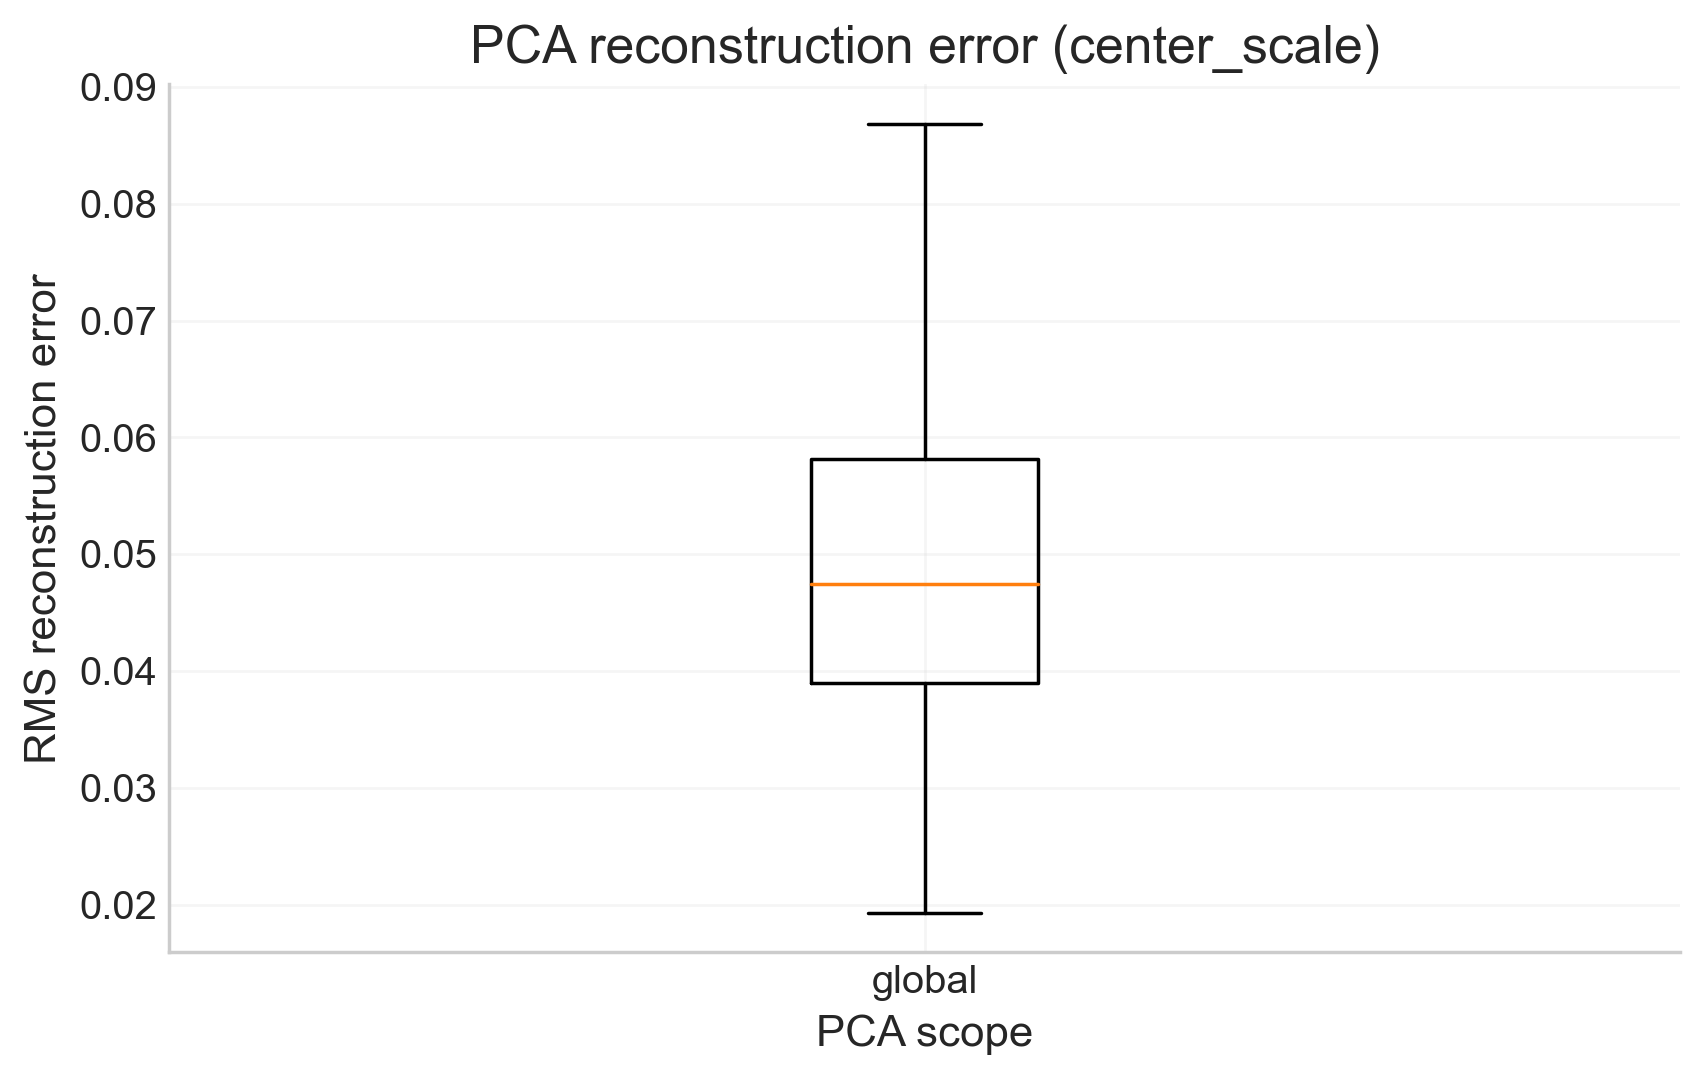

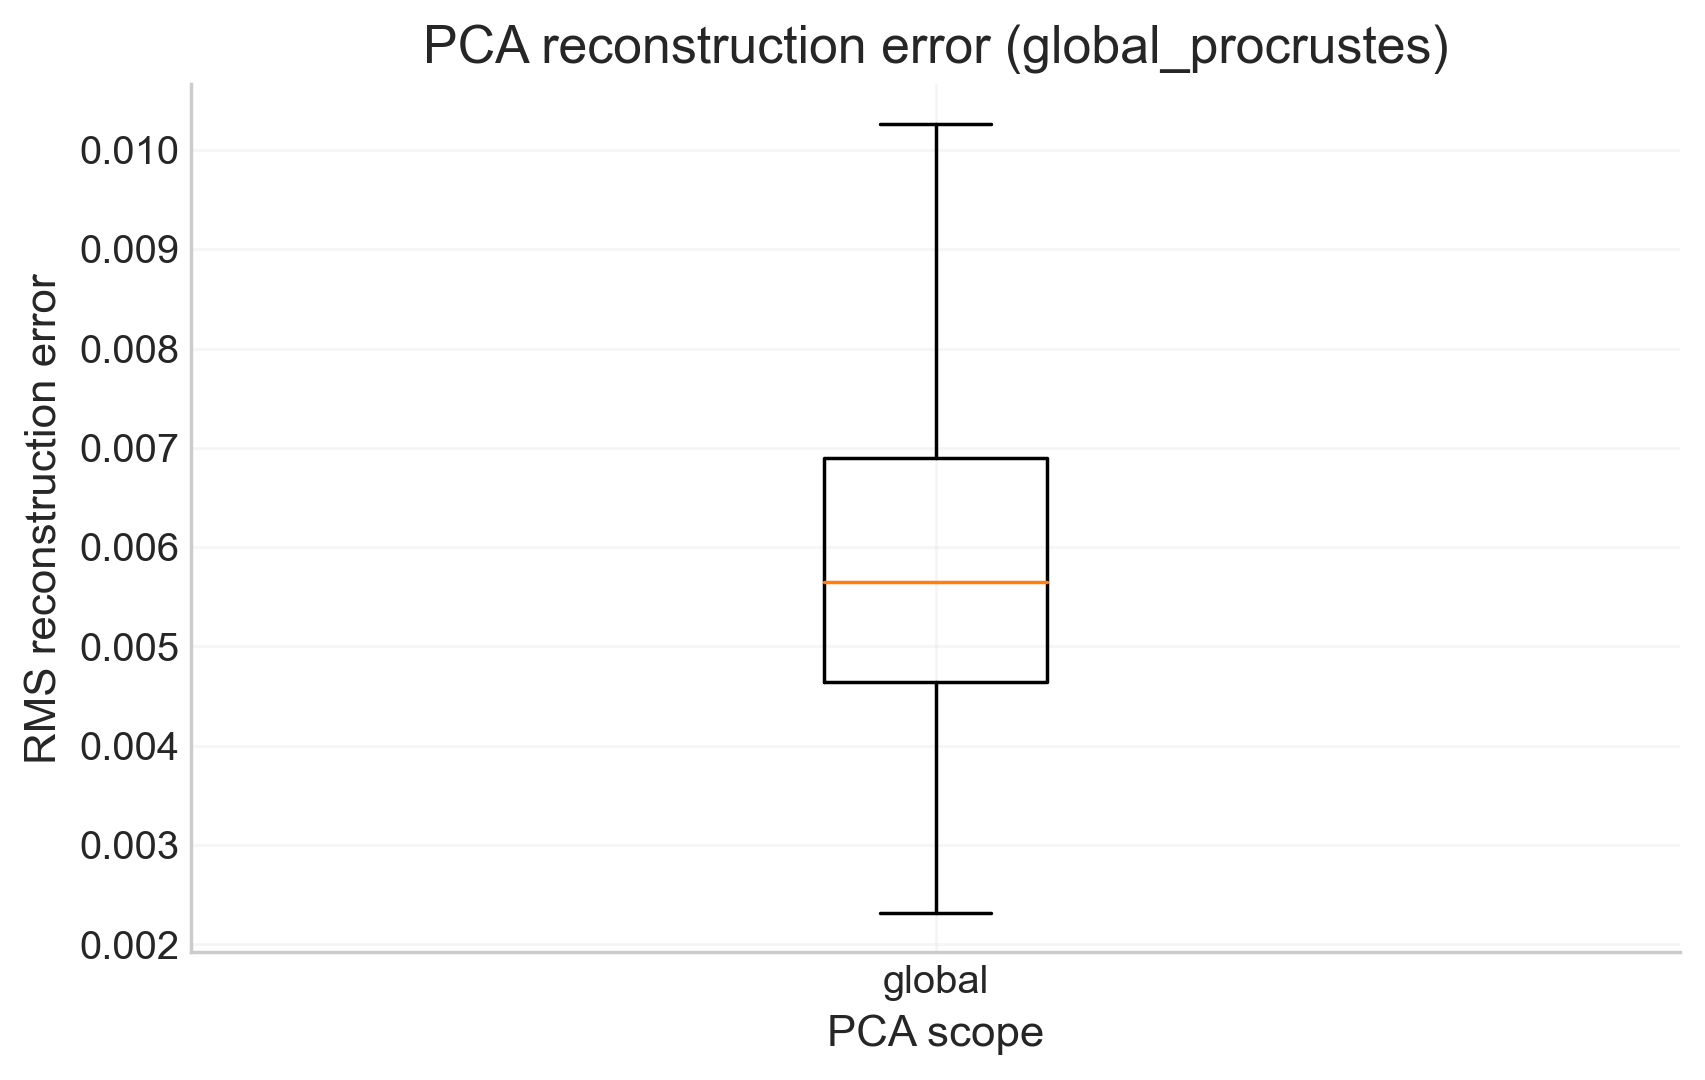

In [ ]:
def plot_reconstruction_error_boxplot(reconstruction_df: pd.DataFrame, representation: str, output_path: Path) -> None:
    """Plot reconstruction errors globally and, optionally, by yaw group."""
    subset = reconstruction_df.query("representation == @representation")
    if subset.empty:
        return
    if RUN_YAW_GROUP_ANALYSIS and subset["yaw_pca_error"].notna().any():
        group_order = [YAW_KEY_TO_LABEL[key] for key in YAW_GROUP_ORDER]
        global_values = [subset.loc[subset["yaw_label"] == label, "global_pca_error"].dropna().values for label in group_order]
        yaw_values = [subset.loc[subset["yaw_label"] == label, "yaw_pca_error"].dropna().values for label in group_order]
        positions_global = np.arange(len(group_order)) * 2.0
        positions_yaw = positions_global + 0.75
        fig, ax = plt.subplots(figsize=(13, 5))
        ax.boxplot(global_values, positions=positions_global, widths=0.6, showfliers=False)
        ax.boxplot(yaw_values, positions=positions_yaw, widths=0.6, showfliers=False)
        ax.set_xticks(positions_global + 0.375)
        ax.set_xticklabels(group_order, rotation=35, ha="right")
        ax.legend(["Global PCA", "Yaw-conditioned PCA"], loc="upper right")
        ax.set_xlabel("Yaw angle")
    else:
        fig, ax = plt.subplots(figsize=(7, 4.5))
        ax.boxplot([subset["global_pca_error"].dropna().values], labels=["global"], showfliers=False)
        ax.set_xlabel("PCA scope")
    ax.set_title(f"PCA reconstruction error ({representation})")
    ax.set_ylabel("RMS reconstruction error")
    fig.tight_layout()
    fig.savefig(output_path, dpi=200)
    plt.show()

plot_reconstruction_error_boxplot(reconstruction_errors, "center_scale", FIGURES_DIR / "reconstruction_error_center_scale.png")
plot_reconstruction_error_boxplot(reconstruction_errors, "global_procrustes", FIGURES_DIR / "reconstruction_error_global_procrustes.png")
if RUN_YAW_GROUP_ANALYSIS:
    plot_reconstruction_error_boxplot(reconstruction_errors, "yaw_procrustes", FIGURES_DIR / "reconstruction_error_yaw_procrustes.png")


## Outlier inspection

The samples with the highest reconstruction error are likely to be unusual shapes, corrupted labels, extreme poses, or samples poorly represented by the selected PCA prior.

In [ ]:
def save_outlier_shape_plots(reconstruction_df: pd.DataFrame, shapes: np.ndarray, samples: Sequence[LandmarkSample], representation: str, error_column: str, output_dir: Path, top_k: int = 20) -> pd.DataFrame:
    """Save plots for top reconstruction-error outliers."""
    output_dir.mkdir(parents=True, exist_ok=True)
    subset = reconstruction_df.query("representation == @representation").copy()
    subset = subset.sort_values(error_column, ascending=False).head(top_k)
    for _, row in subset.iterrows():
        sample_idx = int(row["sample_idx"])
        sample = samples[sample_idx]
        shape = shapes[sample_idx]
        fig, ax = plt.subplots(figsize=(4, 4))
        plot_shape(ax, shape, f"{sample.stem}\n{sample.yaw_label}, {error_column}={row[error_column]:.4f}")
        fig.tight_layout()
        fig.savefig(output_dir / f"{representation}_{error_column}_{sample_idx:05d}_{sample.stem}.png", dpi=200)
        plt.close(fig)
    return subset

outlier_global_center = save_outlier_shape_plots(reconstruction_errors, train_shapes_center_scale, train_samples, "center_scale", "global_pca_error", OUTLIERS_DIR / "center_scale_global", top_k=TOP_K_OUTLIERS)
outlier_global_center.to_csv(TABLES_DIR / "outliers_center_scale_global.csv", index=False)
outlier_global_center.head()


,representation,sample_idx,stem,yaw_key,yaw_angle,yaw_label,global_pca_error,yaw_pca_error,yaw_minus_global_error
11140,center_scale,11140,identity_01220_yaw_p075,yaw_plus_75deg,75.0,+75°,0.127445,NaN,NaN
71,center_scale,71,identity_00009_yaw_m075,yaw_minus_75deg,-75.0,-75°,0.126244,NaN,NaN
6441,center_scale,6441,identity_00698_yaw_m075,yaw_minus_75deg,-75.0,-75°,0.123343,NaN,NaN
844,center_scale,844,identity_00094_yaw_p075,yaw_plus_75deg,75.0,+75°,0.122561,NaN,NaN
11139,center_scale,11139,identity_01220_yaw_p065,yaw_plus_65deg,65.0,+65°,0.121794,NaN,NaN


## Summary tables

This table summarizes reconstruction errors. By default it reports global PCA summaries; when `RUN_YAW_GROUP_ANALYSIS = True`, it also includes per-yaw summaries and yaw-conditioned PCA error columns.


In [ ]:
def summarize_reconstruction_errors(reconstruction_df: pd.DataFrame) -> pd.DataFrame:
    """Summarize reconstruction errors by representation and, optionally, yaw group."""
    group_columns = ["representation"]
    if RUN_YAW_GROUP_ANALYSIS:
        group_columns.extend(["yaw_key", "yaw_label", "yaw_angle"])
    grouped = reconstruction_df.groupby(group_columns, dropna=False)
    summary = grouped.agg(
        mean_global_pca_error=("global_pca_error", "mean"),
        median_global_pca_error=("global_pca_error", "median"),
        mean_yaw_pca_error=("yaw_pca_error", "mean"),
        median_yaw_pca_error=("yaw_pca_error", "median"),
        n_samples=("stem", "count"),
    ).reset_index()
    summary["mean_error_reduction_yaw_vs_global"] = summary["mean_global_pca_error"] - summary["mean_yaw_pca_error"]
    summary["relative_mean_error_reduction"] = summary["mean_error_reduction_yaw_vs_global"] / (summary["mean_global_pca_error"] + 1e-12)
    return summary

reconstruction_summary = summarize_reconstruction_errors(reconstruction_errors)
reconstruction_summary.to_csv(TABLES_DIR / "pca_reconstruction_error_summary.csv", index=False)
reconstruction_summary


,representation,mean_global_pca_error,median_global_pca_error,mean_yaw_pca_error,median_yaw_pca_error,n_samples,mean_error_reduction_yaw_vs_global,relative_mean_error_reduction
0,center_scale,0.050028,0.047436,NaN,NaN,11375,NaN,NaN
1,global_procrustes,0.005946,0.005651,NaN,NaN,11375,NaN,NaN


## Extended synthetic outputs

This section adds the same family of exported tables and figures used in the natural-dataset internal analysis notebook, but focused exclusively on the synthetic train split.

Method note:
- geometric synthetic analyses use all finite landmark coordinates,
- visibility is still summarized and exported as a descriptive signal,
- PCA reconstructions here use the truncated PCA subspace already selected for each fitted model.


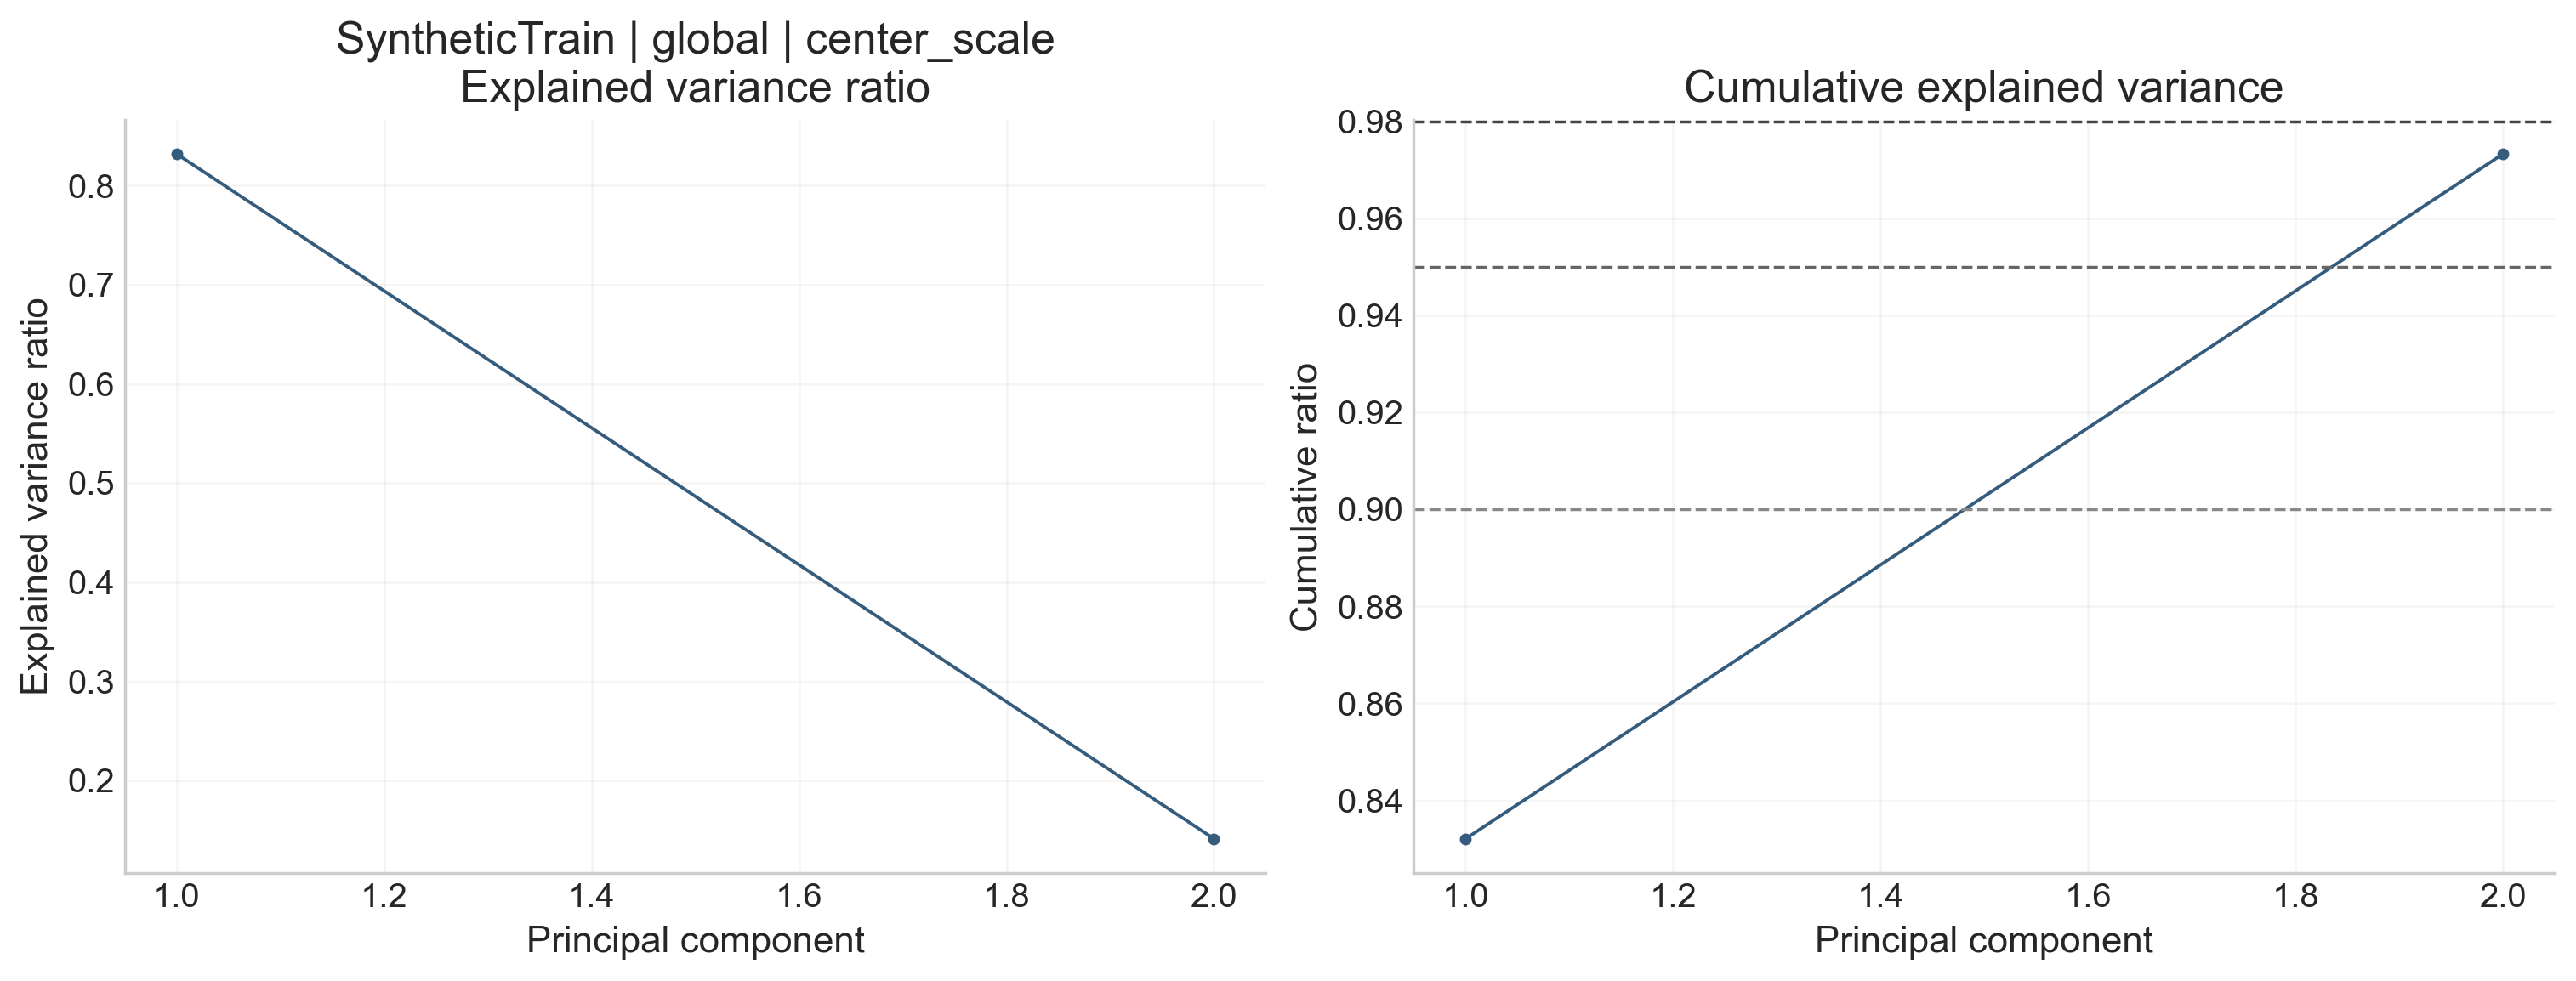

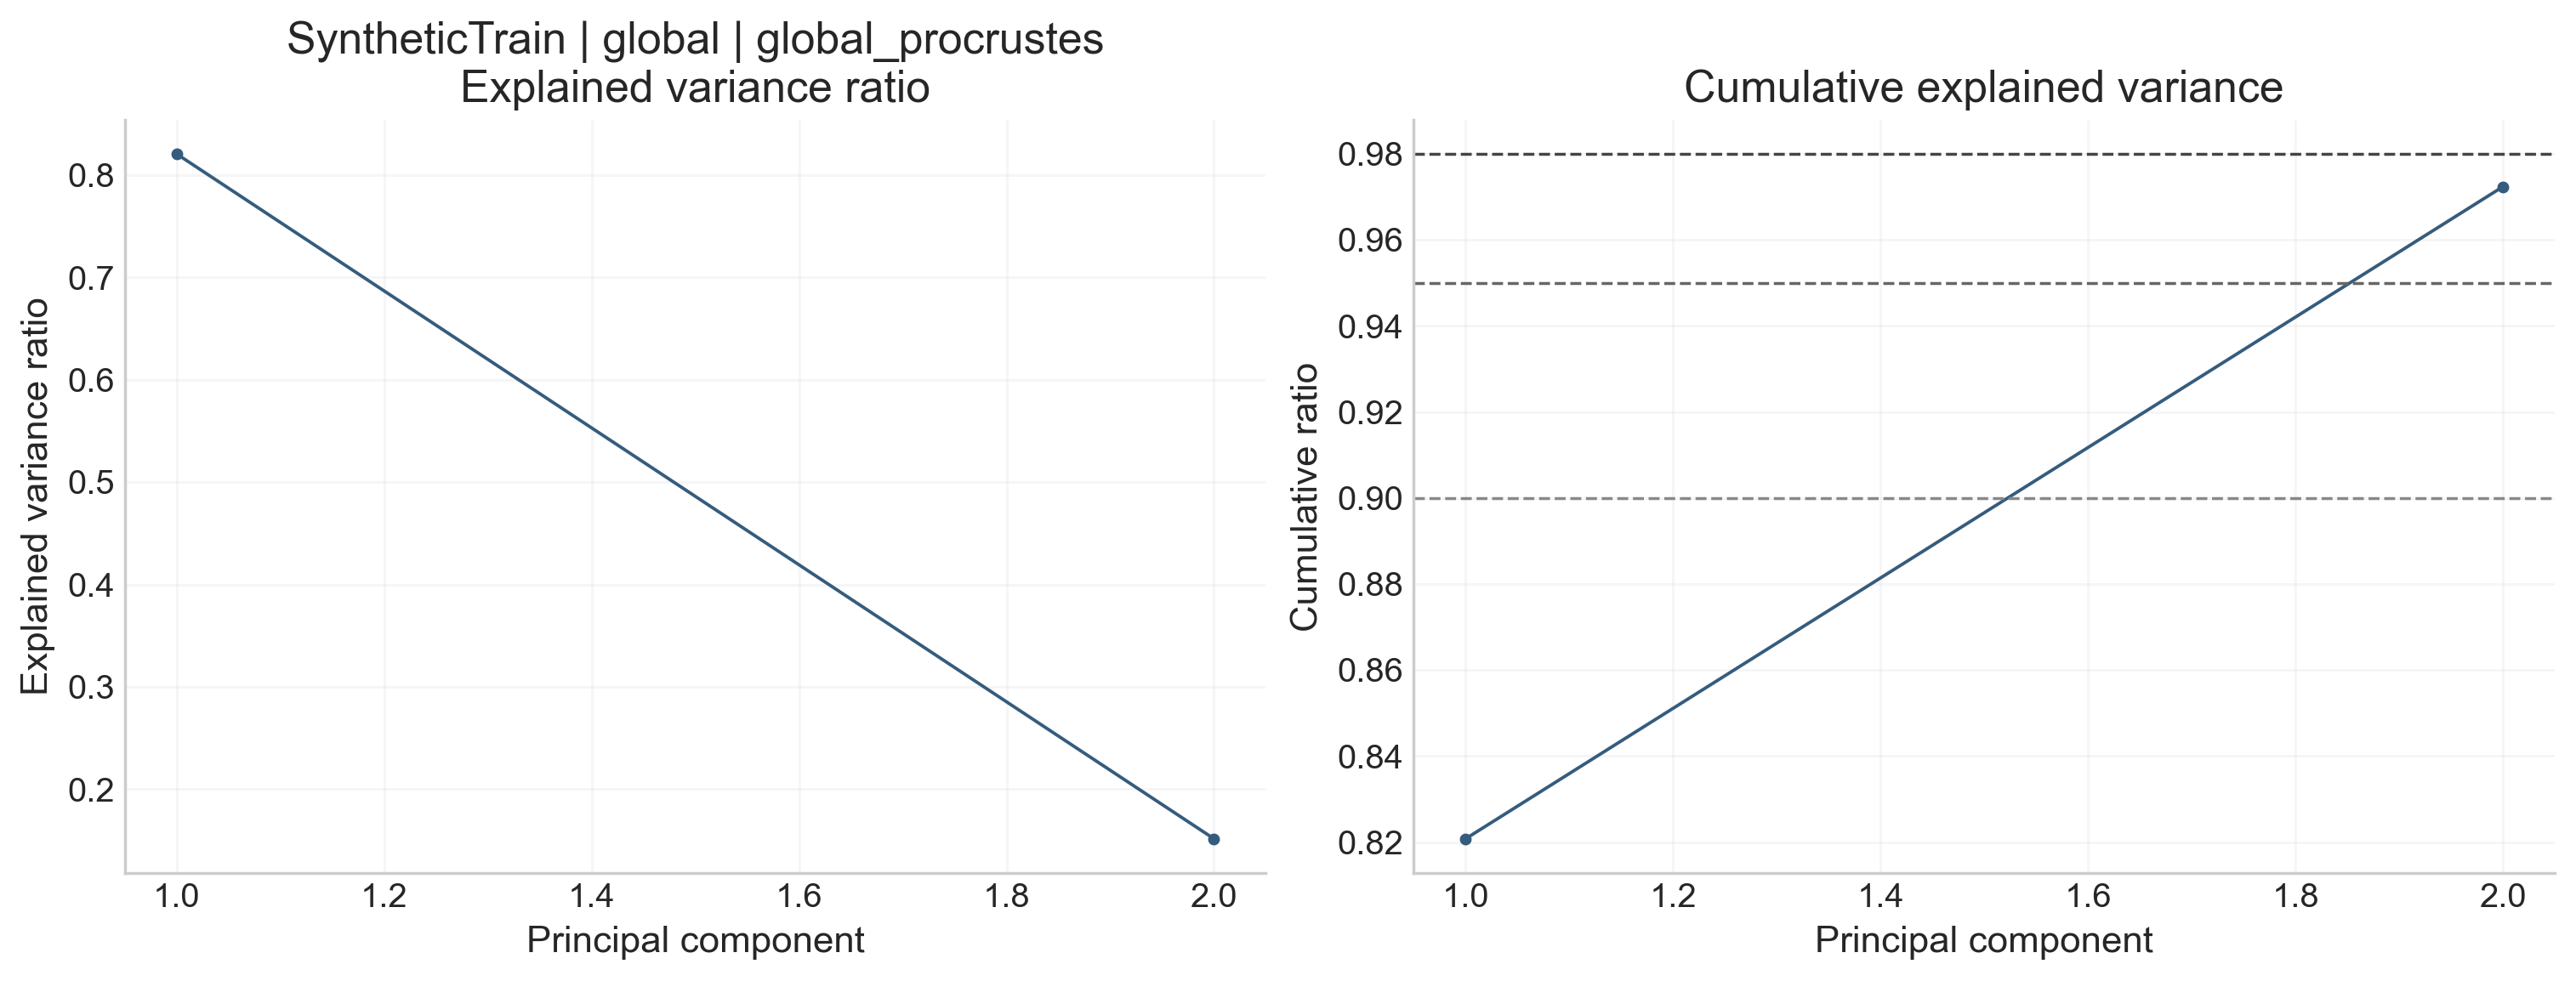

Extended synthetic outputs refreshed for global PCA.


In [ ]:
def save_table(df: pd.DataFrame, filename: str | Path) -> Path:
    output_path = TABLES_DIR / Path(filename)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(output_path, index=False)
    return output_path


def save_figure(fig: plt.Figure, relative_stem: str | Path) -> dict[str, Path]:
    stem = Path(relative_stem)
    png_path = FIGURES_DIR / f"{stem}.png"
    png_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(png_path, dpi=FIG_DPI, bbox_inches="tight")
    saved = {"png": png_path}
    if SAVE_PDF:
        pdf_path = FIGURES_DIR / f"{stem}.pdf"
        fig.savefig(pdf_path, bbox_inches="tight")
        saved["pdf"] = pdf_path
    return saved


def pca_label_prefix(pca: PCAResult) -> str:
    method = pca.representation
    if pca.yaw_key is None:
        return f"global_72_{method}"
    return f"{pca.yaw_key}_72_{method}"


def pca_title_scope(pca: PCAResult) -> str:
    return "global" if pca.yaw_key is None else str(pca.yaw_label)


def yaw_distribution_table() -> pd.DataFrame:
    counts = pd.Series(train_yaw_keys).value_counts().reindex(YAW_GROUP_ORDER, fill_value=0)
    table = pd.DataFrame({
        "yaw_key": counts.index,
        "yaw_angle": [YAW_KEY_TO_ANGLE[key] for key in counts.index],
        "yaw_label": [YAW_KEY_TO_LABEL[key] for key in counts.index],
        "count": counts.values,
    })
    table["percentage"] = 100.0 * table["count"] / max(int(table["count"].sum()), 1)
    return table


def pca_experiment_rows(pcas: Dict[str, PCAResult]) -> pd.DataFrame:
    rows = []
    for key, pca in pcas.items():
        cumulative = np.cumsum(pca.explained_variance_ratio)
        rows.append({
            "experiment_key": key,
            "export_prefix": pca_label_prefix(pca),
            "scope": pca.scope,
            "yaw_key": pca.yaw_key,
            "yaw_label": pca.yaw_label,
            "representation": pca.representation,
            "n_samples": len(pca.sample_indices),
            "num_components": int(pca.components.shape[0]),
            "components_for_90pct": int(np.searchsorted(cumulative, 0.90) + 1) if len(cumulative) else 0,
            "components_for_95pct": int(np.searchsorted(cumulative, 0.95) + 1) if len(cumulative) else 0,
            "components_for_98pct": int(np.searchsorted(cumulative, 0.98) + 1) if len(cumulative) else 0,
        })
    return pd.DataFrame(rows)


def plot_explained_variance_trip(pca: PCAResult, figure_stem: str) -> None:
    ratio = pca.explained_variance_ratio
    cumulative = np.cumsum(ratio)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
    idx = np.arange(1, len(ratio) + 1)
    axes[0].plot(idx, ratio, marker="o", linewidth=1.1, markersize=3.0, color=DATASET_COLORS["SyntheticTrain"])
    axes[0].set_title(f"SyntheticTrain | {pca_title_scope(pca)} | {pca.representation}\nExplained variance ratio")
    axes[0].set_xlabel("Principal component")
    axes[0].set_ylabel("Explained variance ratio")
    axes[1].plot(idx, cumulative, marker="o", linewidth=1.1, markersize=3.0, color=DATASET_COLORS["SyntheticTrain"])
    axes[1].axhline(0.90, color="#888888", linestyle="--", linewidth=1)
    axes[1].axhline(0.95, color="#666666", linestyle="--", linewidth=1)
    axes[1].axhline(0.98, color="#444444", linestyle="--", linewidth=1)
    axes[1].set_title("Cumulative explained variance")
    axes[1].set_xlabel("Principal component")
    axes[1].set_ylabel("Cumulative ratio")
    save_figure(fig, figure_stem)
    plt.show()


yaw_table = yaw_distribution_table()
save_table(yaw_table, "synthetic_yaw_distribution.csv")

synthetic_pca_summary = pca_experiment_rows(pca_results)
save_table(synthetic_pca_summary, "synthetic_pca_explained_variance_summary.csv")

for key, pca in pca_results.items():
    prefix = pca_label_prefix(pca)
    plot_explained_variance_trip(pca, f"{prefix}_explained_variance")

print("Extended synthetic outputs refreshed for global PCA" + (" and per-yaw PCA." if RUN_YAW_GROUP_ANALYSIS else "."))


## Optional: save PCA candidates

This cell saves PCA candidates as `.npz` files for inspection. This is not the final training `.pt` prior format, but it lets you archive the analysis output. The training prior should later be generated by a dedicated script once you decide the final design.

In [ ]:
def save_pca_results_npz(pcas: Dict[str, PCAResult], output_path: Path) -> None:
    """Save PCA results to a compressed NumPy archive."""
    arrays = {}
    metadata_rows = []
    for key, pca in pcas.items():
        safe_key = key.replace("/", "_")
        arrays[f"{safe_key}__mean_vector"] = pca.mean_vector
        arrays[f"{safe_key}__components"] = pca.components
        arrays[f"{safe_key}__explained_variance"] = pca.explained_variance
        arrays[f"{safe_key}__explained_variance_ratio"] = pca.explained_variance_ratio
        metadata_rows.append(
            {
                "key": key,
                "scope": pca.scope,
                "yaw_key": pca.yaw_key,
                "yaw_label": pca.yaw_label if pca.yaw_label is not None else "global",
                "representation": pca.representation,
                "n_samples": len(pca.sample_indices),
                "n_components": pca.components.shape[0],
            }
        )
    metadata = pd.DataFrame(metadata_rows)
    arrays["metadata_csv"] = metadata.to_csv(index=False).encode("utf-8")
    np.savez_compressed(output_path, **arrays)

save_pca_results_npz(pca_results, OUTPUT_ROOT / "pca_analysis_candidates.npz")
print(f"Saved PCA candidates to: {OUTPUT_ROOT / 'pca_analysis_candidates.npz'}")


Saved PCA candidates to: /Users/jocareher/Documents/synbaby72_analysis/pca_analysis_candidates.npz


## Final checklist for interpretation

Use the generated outputs to answer these questions:

1. Does global PC1 mostly capture yaw?
2. Are global PCA scores multimodal by yaw angle?
3. Does global Procrustes reduce nuisance variation or hide meaningful yaw variation?
4. If `RUN_YAW_GROUP_ANALYSIS = True`, do per-yaw PCA score distributions look closer to normal?
5. If `RUN_YAW_GROUP_ANALYSIS = True`, how much reconstruction error is reduced by yaw-conditioned PCA?
6. Which PCA design is most defensible for the next experiment?


Component coverage is controlled from the configuration cell:

```text
MAX_COMPONENTS_TO_VISUALIZE
SCORE_COMPONENTS_TO_VISUALIZE
SCORE_SCATTER_COMPONENTS_TO_PLOT
SCORE_GRID_COMPONENTS
```

Key outputs:

```text
tables/synthetic_yaw_distribution.csv
tables/pca_explained_variance.csv
tables/pca_score_statistics.csv
tables/pca_reconstruction_errors.csv
tables/pca_reconstruction_error_summary.csv
figures/pca_component_global__center_scale_pc01.png
figures/pca_component_global__center_scale_pc10.png
figures/score_hist_global__center_scale_pc10.png
figures/score_scatter_global__center_scale_pc1_pc2.png
figures/score_scatter_global__center_scale_pc5_pc6.png
figures/pairwise_score_grid_global__center_scale.png
figures/reconstruction_error_center_scale.png
```
